In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
bumba5341_advertisingcsv_path = kagglehub.dataset_download('bumba5341/advertisingcsv')

print('Data source import complete.')


Using Colab cache for faster access to the 'advertisingcsv' dataset.
Data source import complete.


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/advertisingcsv/Advertising.csv


In [5]:
# ============================================
# TASK 5: SALES PREDICTION WITH MACHINE LEARNING
# ============================================
# OASIS INFOBYTE - DATA SCIENCE INTERNSHIP
# Dataset: Advertising.csv (TV, Radio, Newspaper spend vs Sales)
# Author: Rakshita R Talegaon
# ============================================

INSTALLATION & SETUP

In [6]:
!pip install -q xgboost lightgbm catboost optuna shap plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 36.1 MB/s eta 0:00:00


IMPORT LIBRARIES

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
import os
from datetime import datetime

# Suppress warnings
warnings.filterwarnings('ignore')

# Advanced visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                           r2_score, mean_absolute_percentage_error)

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                            AdaBoostRegressor, ExtraTreesRegressor,
                            VotingRegressor, StackingRegressor)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Hyperparameter Optimization
import optuna

# Statistical analysis
from scipy import stats
from sklearn.feature_selection import mutual_info_regression

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


LOAD DATASET

In [9]:
print("="*60)
print("STEP 1: LOADING DATASET")
print("="*60)

# Load the dataset
file_path = '/kaggle/input/advertisingcsv/Advertising.csv'

try:
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully from Kaggle")
except:
    df = pd.read_csv('Advertising.csv')
    print("✅ Dataset loaded from local path")

print(f"\n📊 Dataset Shape: {df.shape}")
print(f"\n📋 First 5 rows:")
print(df.head())

print(f"\n📋 Column Names: {df.columns.tolist()}")

# Check if first column is unnamed index
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("✅ Dropped unnamed index column")

print(f"\n📋 Final Columns: {df.columns.tolist()}")
print(f"\n📊 Data Types:\n{df.dtypes}")

STEP 1: LOADING DATASET
✅ Dataset loaded successfully from Kaggle

📊 Dataset Shape: (200, 5)

📋 First 5 rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

📋 Column Names: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']
✅ Dropped unnamed index column

📋 Final Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

📊 Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


DATA PREPROCESSING & CLEANING

STEP 2: DATA PREPROCESSING

🔍 Missing Values:
   No missing values found!

🔍 Duplicates: 0

📊 Dataset Info:
   - Total samples: 200
   - Features: 4
   - Memory usage: 0.01 MB

📊 Statistical Summary:
           TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   14.02
std     85.85   14.85      21.78    5.22
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   10.38
50%    149.75   22.90      25.75   12.90
75%    218.82   36.52      45.10   17.40
max    296.40   49.60     114.00   27.00


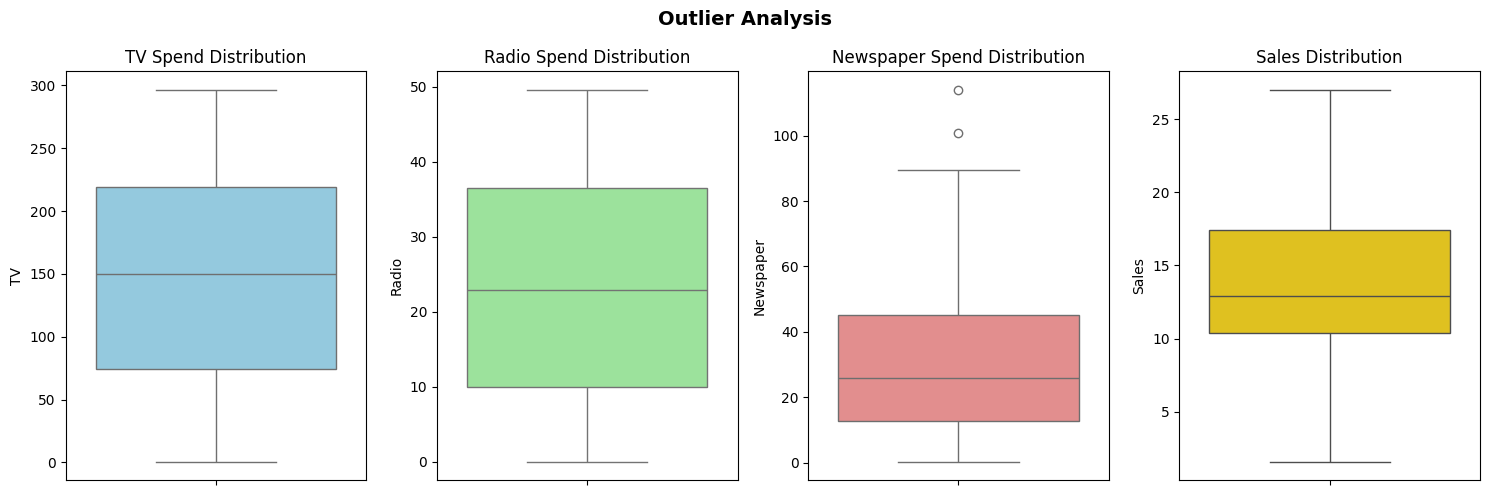


📊 Sales Statistics:
   - Min Sales: 1.60
   - Max Sales: 27.00
   - Mean Sales: 14.02
   - Median Sales: 12.90
   - Std Dev: 5.22


In [10]:
print("="*60)
print("STEP 2: DATA PREPROCESSING")
print("="*60)

# Create a copy
df_clean = df.copy()

# Check missing values
print("\n🔍 Missing Values:")
missing = df_clean.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "   No missing values found!")

# Check duplicates
duplicates = df_clean.duplicated().sum()
print(f"\n🔍 Duplicates: {duplicates}")

# Basic info
print(f"\n📊 Dataset Info:")
print(f"   - Total samples: {len(df_clean)}")
print(f"   - Features: {df_clean.shape[1]}")
print(f"   - Memory usage: {df_clean.memory_usage().sum() / 1024**2:.2f} MB")

# Statistical summary
print("\n📊 Statistical Summary:")
print(df_clean.describe().round(2))

# Check for outliers
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
sns.boxplot(y=df_clean['TV'], color='skyblue')
plt.title('TV Spend Distribution')

plt.subplot(1, 4, 2)
sns.boxplot(y=df_clean['Radio'], color='lightgreen')
plt.title('Radio Spend Distribution')

plt.subplot(1, 4, 3)
sns.boxplot(y=df_clean['Newspaper'], color='lightcoral')
plt.title('Newspaper Spend Distribution')

plt.subplot(1, 4, 4)
sns.boxplot(y=df_clean['Sales'], color='gold')
plt.title('Sales Distribution')

plt.suptitle('Outlier Analysis', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Sales statistics
print(f"\n📊 Sales Statistics:")
print(f"   - Min Sales: {df_clean['Sales'].min():.2f}")
print(f"   - Max Sales: {df_clean['Sales'].max():.2f}")
print(f"   - Mean Sales: {df_clean['Sales'].mean():.2f}")
print(f"   - Median Sales: {df_clean['Sales'].median():.2f}")
print(f"   - Std Dev: {df_clean['Sales'].std():.2f}")

EXPLORATORY DATA ANALYSIS

STEP 3: EXPLORATORY DATA ANALYSIS

📊 Generating Pair Plot...


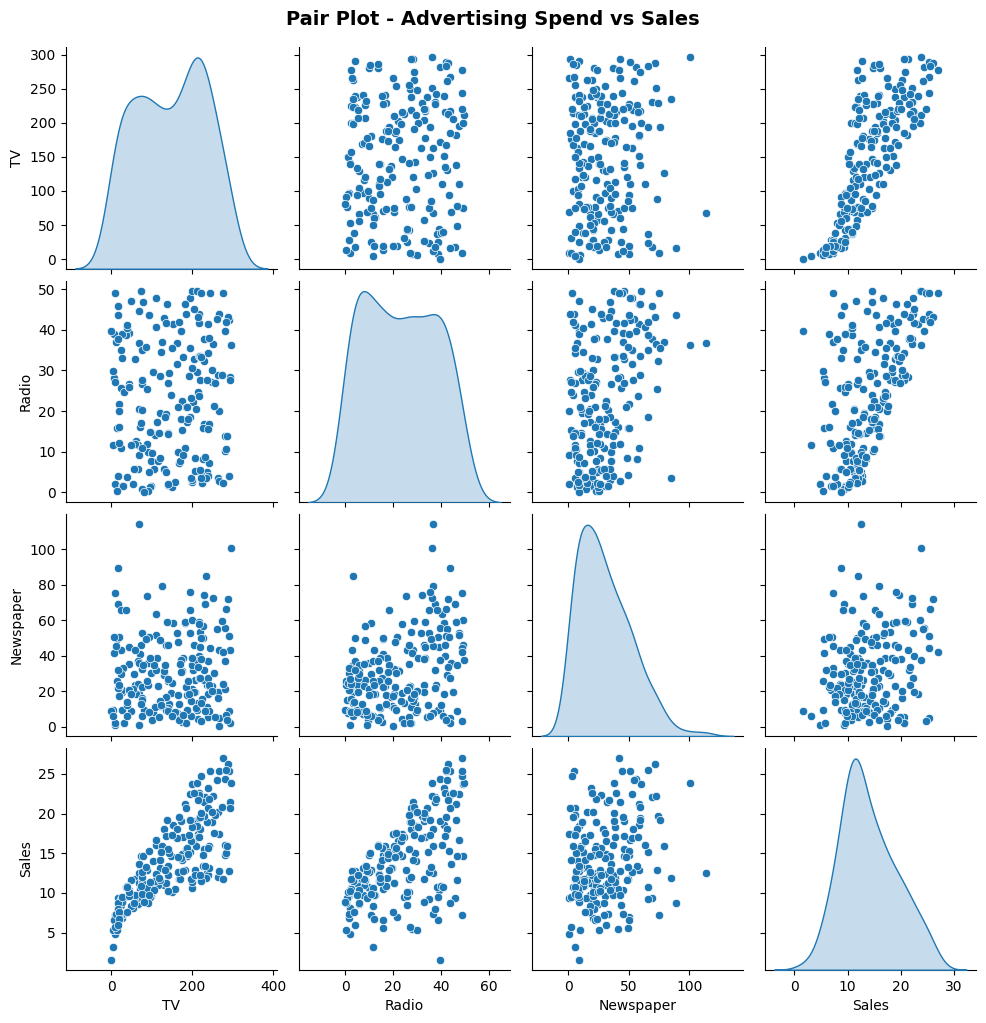

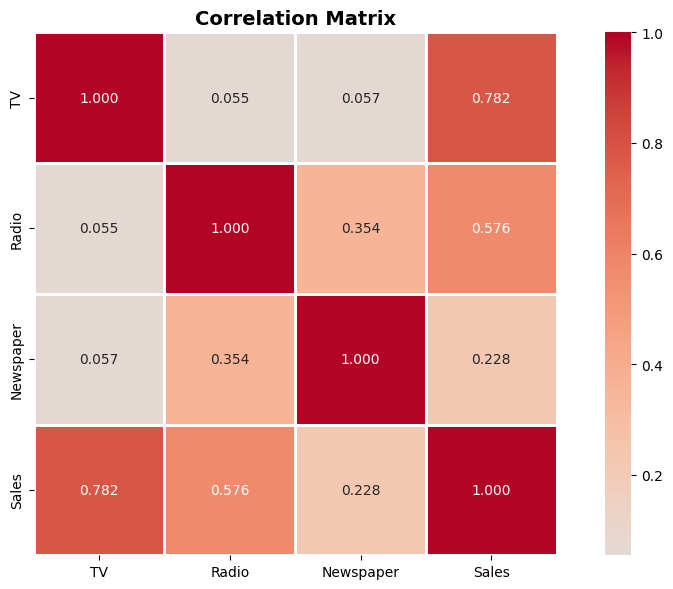


📊 Correlation with Sales:
   1. TV: 0.782 (Strong correlation)
   2. Radio: 0.576 (Moderate correlation)
   3. Newspaper: 0.228 (Weak correlation)


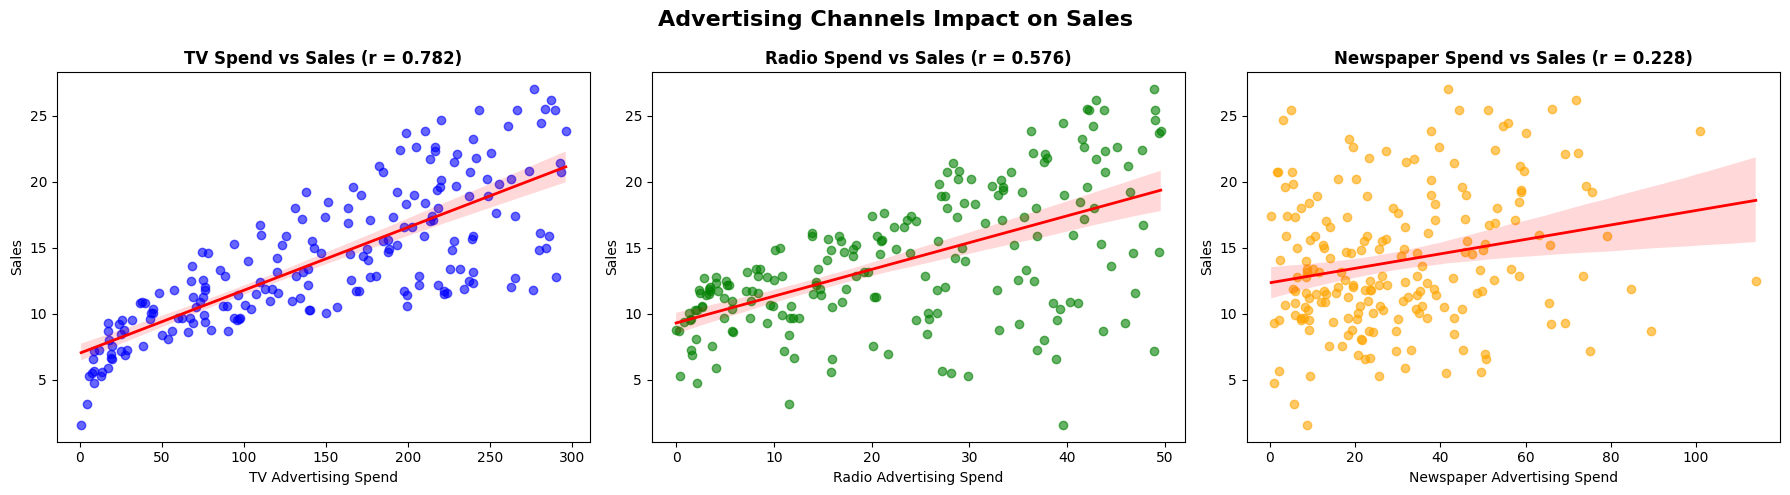

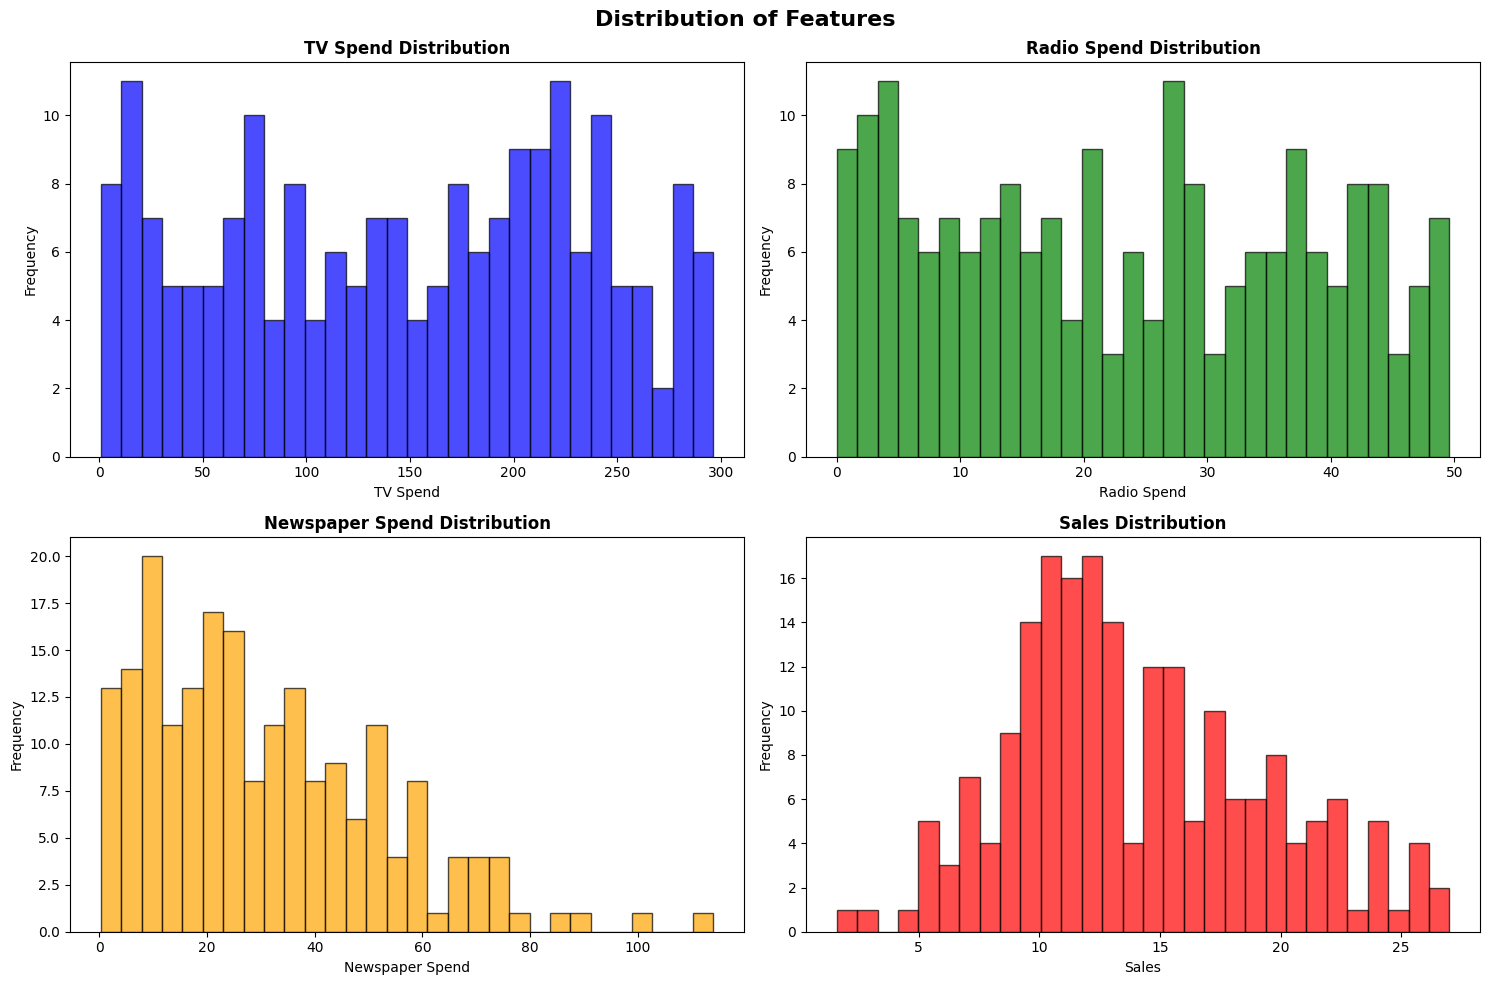

In [11]:
print("="*60)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1. Pairplot to see relationships
print("\n📊 Generating Pair Plot...")
sns.pairplot(df_clean, diag_kind='kde')
plt.suptitle('Pair Plot - Advertising Spend vs Sales', fontweight='bold', fontsize=14, y=1.02)
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(10, 6))
correlation = df_clean.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f')
plt.title('Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📊 Correlation with Sales:")
corr_with_sales = correlation['Sales'].drop('Sales').sort_values(ascending=False)
for idx, (channel, corr) in enumerate(corr_with_sales.items(), 1):
    strength = "Very Strong" if abs(corr) > 0.8 else "Strong" if abs(corr) > 0.6 else "Moderate" if abs(corr) > 0.4 else "Weak"
    print(f"   {idx}. {channel}: {corr:.3f} ({strength} correlation)")

# 3. Scatter plots with regression lines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TV vs Sales
sns.regplot(data=df_clean, x='TV', y='Sales', ax=axes[0],
            scatter_kws={'alpha':0.6, 'color':'blue'},
            line_kws={'color':'red', 'linewidth':2})
axes[0].set_title(f'TV Spend vs Sales (r = {correlation["TV"]["Sales"]:.3f})', fontweight='bold')
axes[0].set_xlabel('TV Advertising Spend')
axes[0].set_ylabel('Sales')

# Radio vs Sales
sns.regplot(data=df_clean, x='Radio', y='Sales', ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'green'},
            line_kws={'color':'red', 'linewidth':2})
axes[1].set_title(f'Radio Spend vs Sales (r = {correlation["Radio"]["Sales"]:.3f})', fontweight='bold')
axes[1].set_xlabel('Radio Advertising Spend')
axes[1].set_ylabel('Sales')

# Newspaper vs Sales
sns.regplot(data=df_clean, x='Newspaper', y='Sales', ax=axes[2],
            scatter_kws={'alpha':0.6, 'color':'orange'},
            line_kws={'color':'red', 'linewidth':2})
axes[2].set_title(f'Newspaper Spend vs Sales (r = {correlation["Newspaper"]["Sales"]:.3f})', fontweight='bold')
axes[2].set_xlabel('Newspaper Advertising Spend')
axes[2].set_ylabel('Sales')

plt.suptitle('Advertising Channels Impact on Sales', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(df_clean['TV'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('TV Spend Distribution', fontweight='bold')
axes[0,0].set_xlabel('TV Spend')
axes[0,0].set_ylabel('Frequency')

axes[0,1].hist(df_clean['Radio'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Radio Spend Distribution', fontweight='bold')
axes[0,1].set_xlabel('Radio Spend')
axes[0,1].set_ylabel('Frequency')

axes[1,0].hist(df_clean['Newspaper'], bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1,0].set_title('Newspaper Spend Distribution', fontweight='bold')
axes[1,0].set_xlabel('Newspaper Spend')
axes[1,0].set_ylabel('Frequency')

axes[1,1].hist(df_clean['Sales'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1,1].set_title('Sales Distribution', fontweight='bold')
axes[1,1].set_xlabel('Sales')
axes[1,1].set_ylabel('Frequency')

plt.suptitle('Distribution of Features', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

ADVANCED DATA VISUALIZATIONS

STEP: ADVANCED DATA VISUALIZATIONS

📊 1. Interactive 3D Scatter Plot - TV, Radio, Sales



📊 2. Bubble Chart - All Channels vs Sales



📊 3. Parallel Coordinates Plot - Multi-dimensional View



📊 4. Enhanced Correlation Heatmap


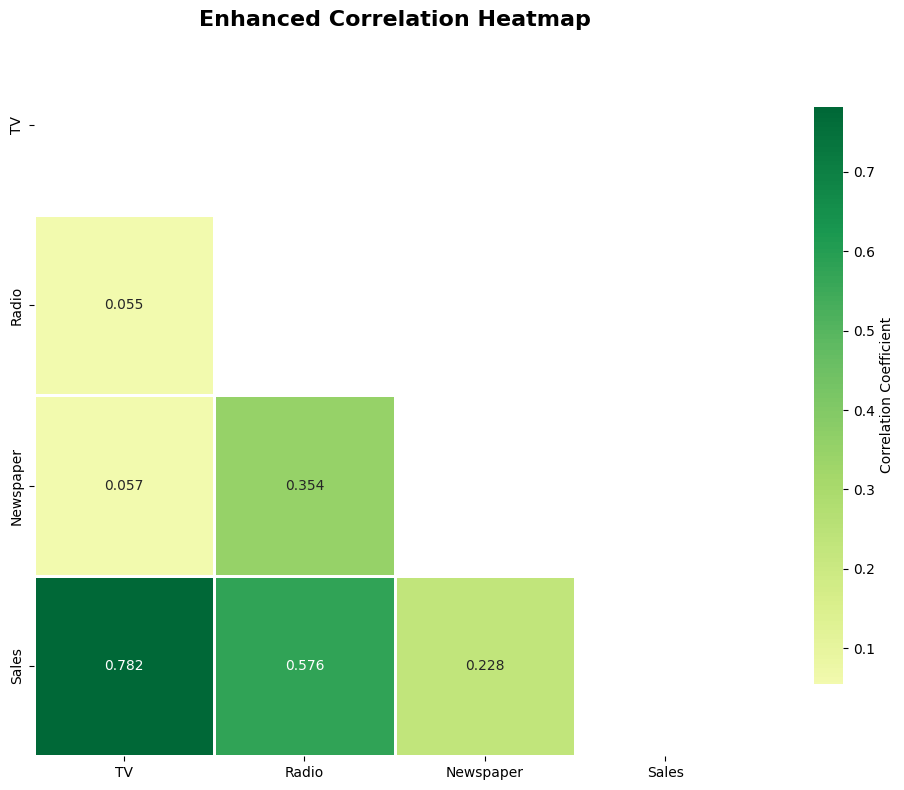


📊 5. Radar Chart - Channel Comparison



📊 6. Sunburst Chart - Budget Distribution



📊 7. Violin Plots - Distribution Analysis


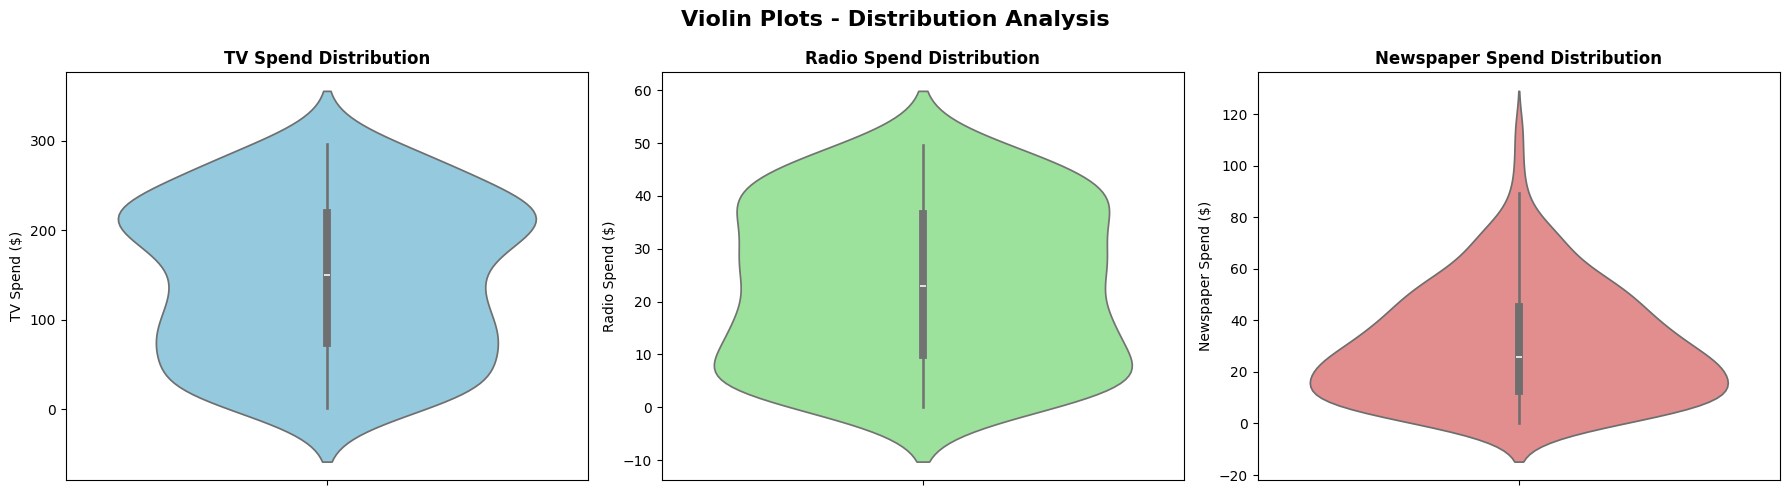


📊 8. Enhanced Pairplot with Regression


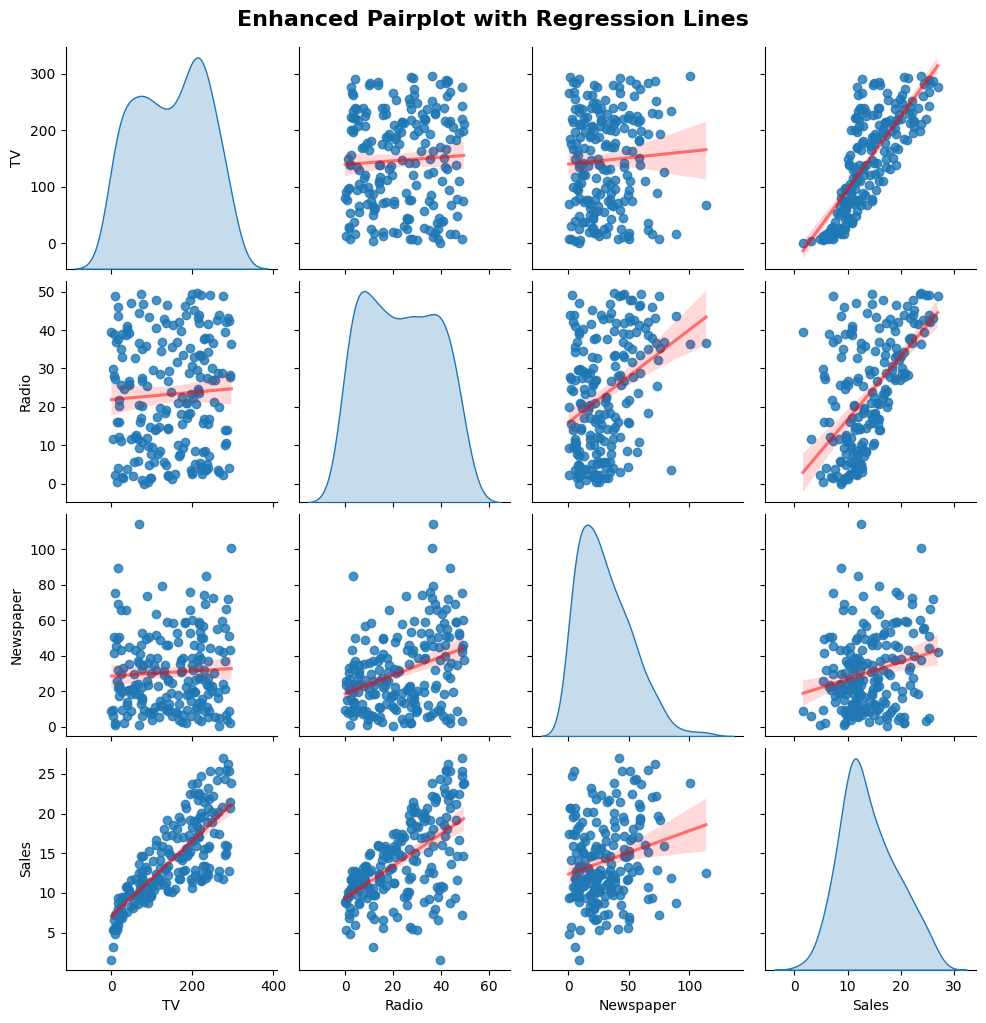


📊 9. Box Plot with Swarm - Detailed Distribution


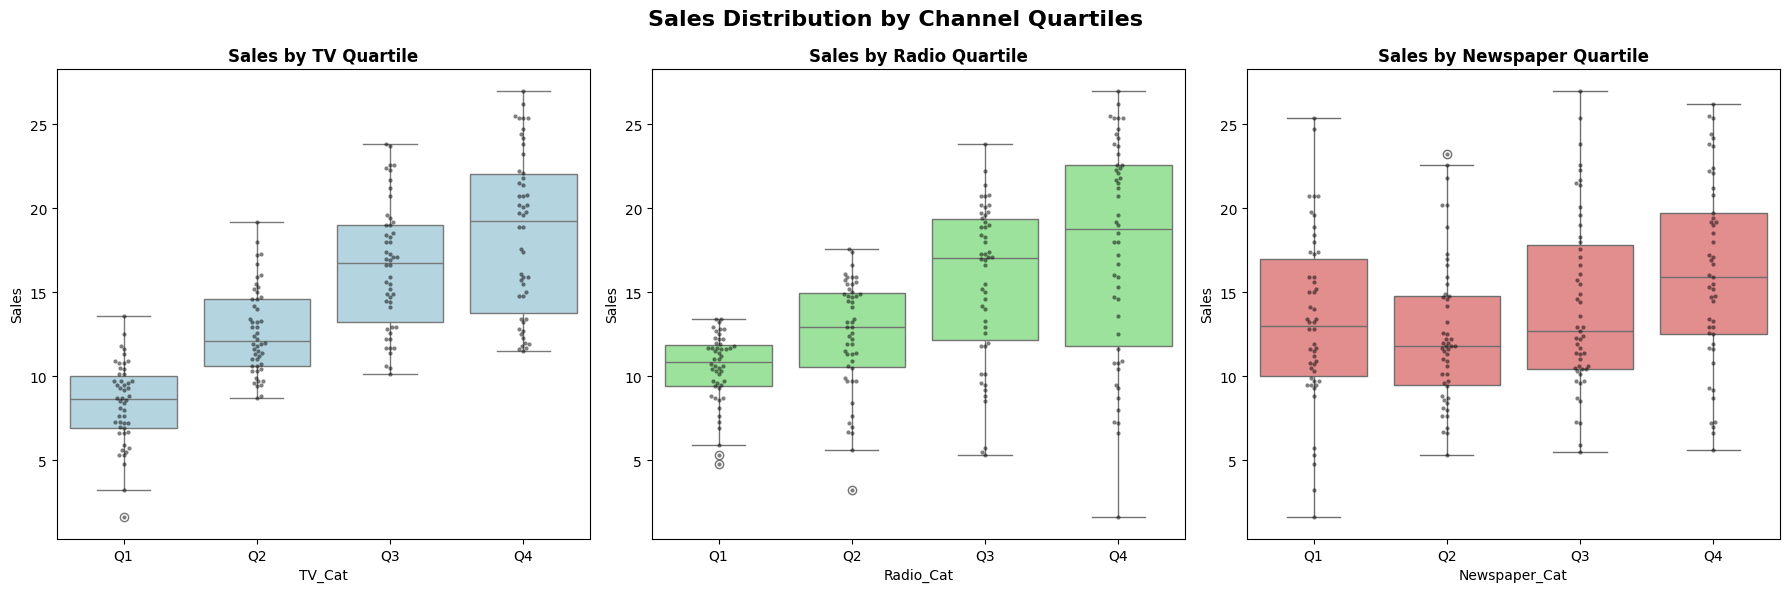


📊 10. Area Chart - Cumulative Impact


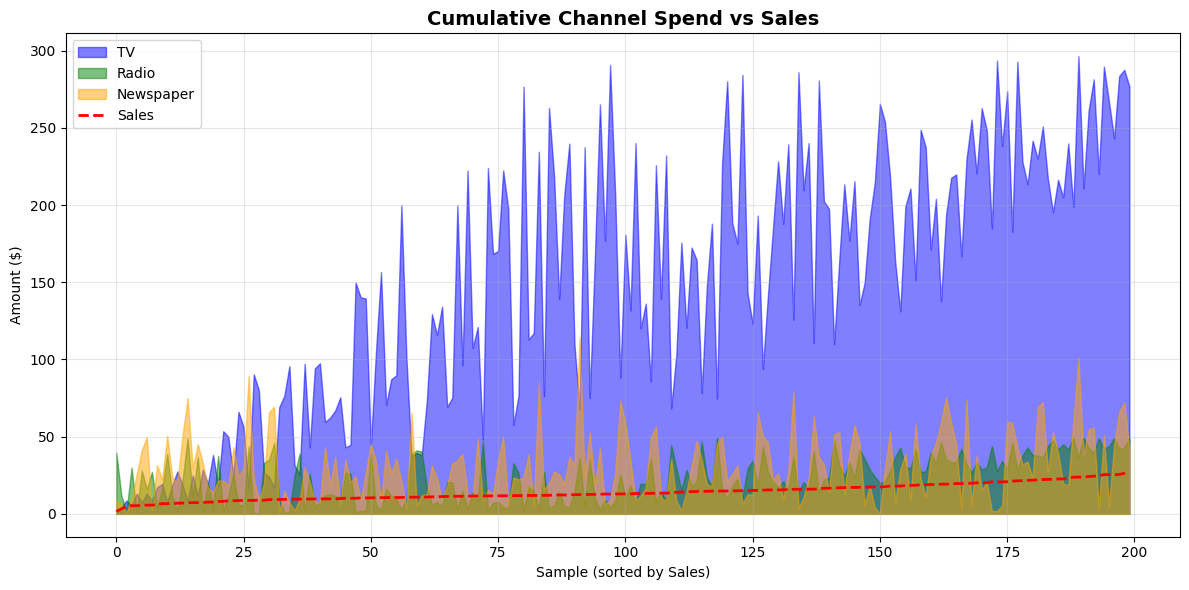


📊 11. 3D Surface Plot - TV & Radio Interaction



📊 12. Joint Plot - TV vs Sales


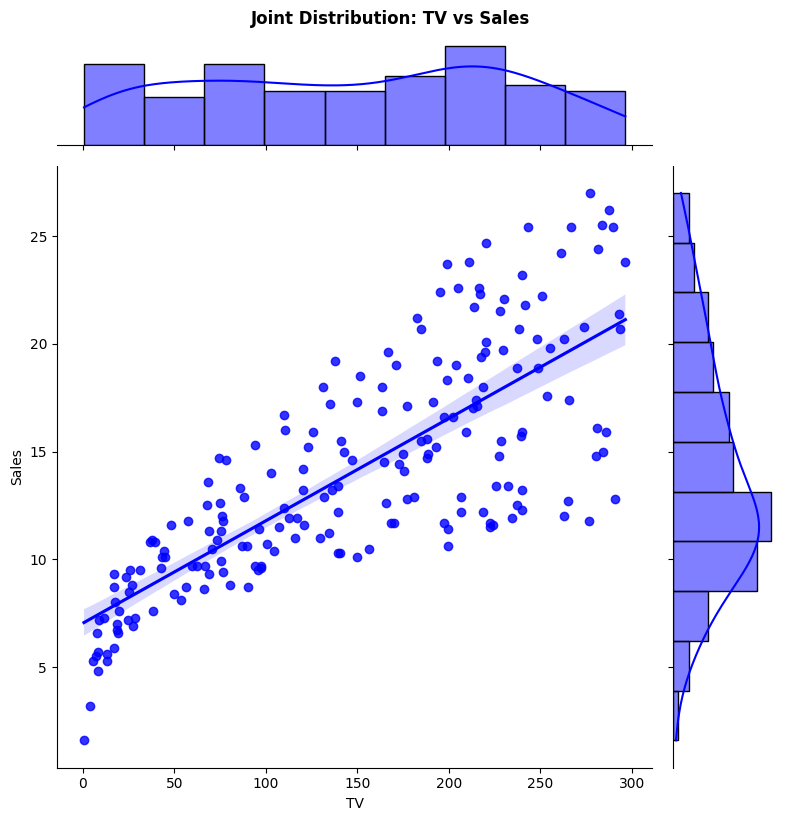


📊 13. Joint Plot - Radio vs Sales


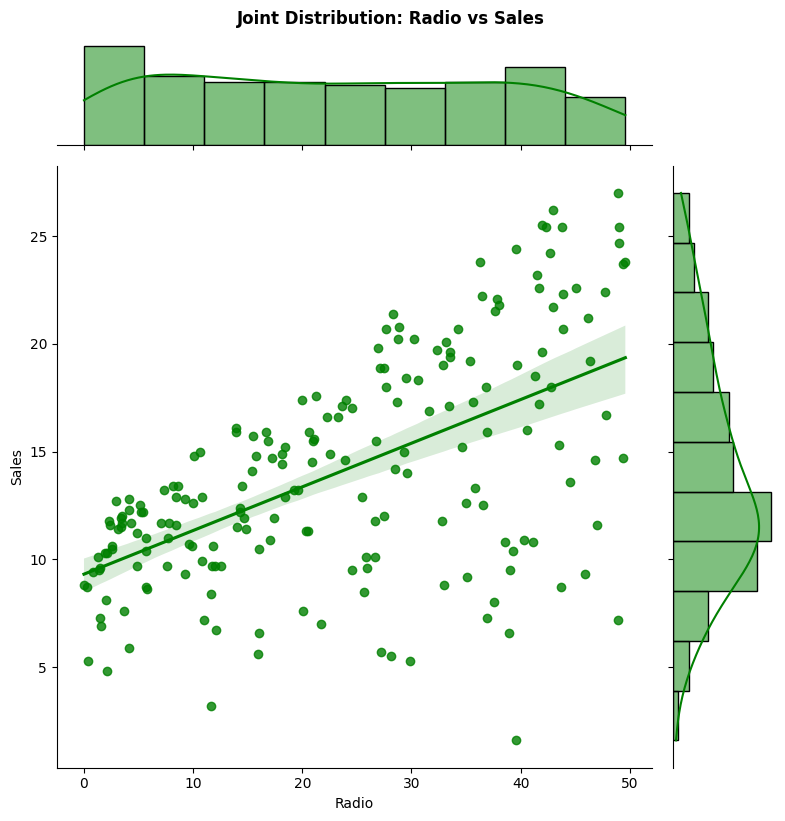


📊 14. Facet Grid - Sales by Multiple Conditions


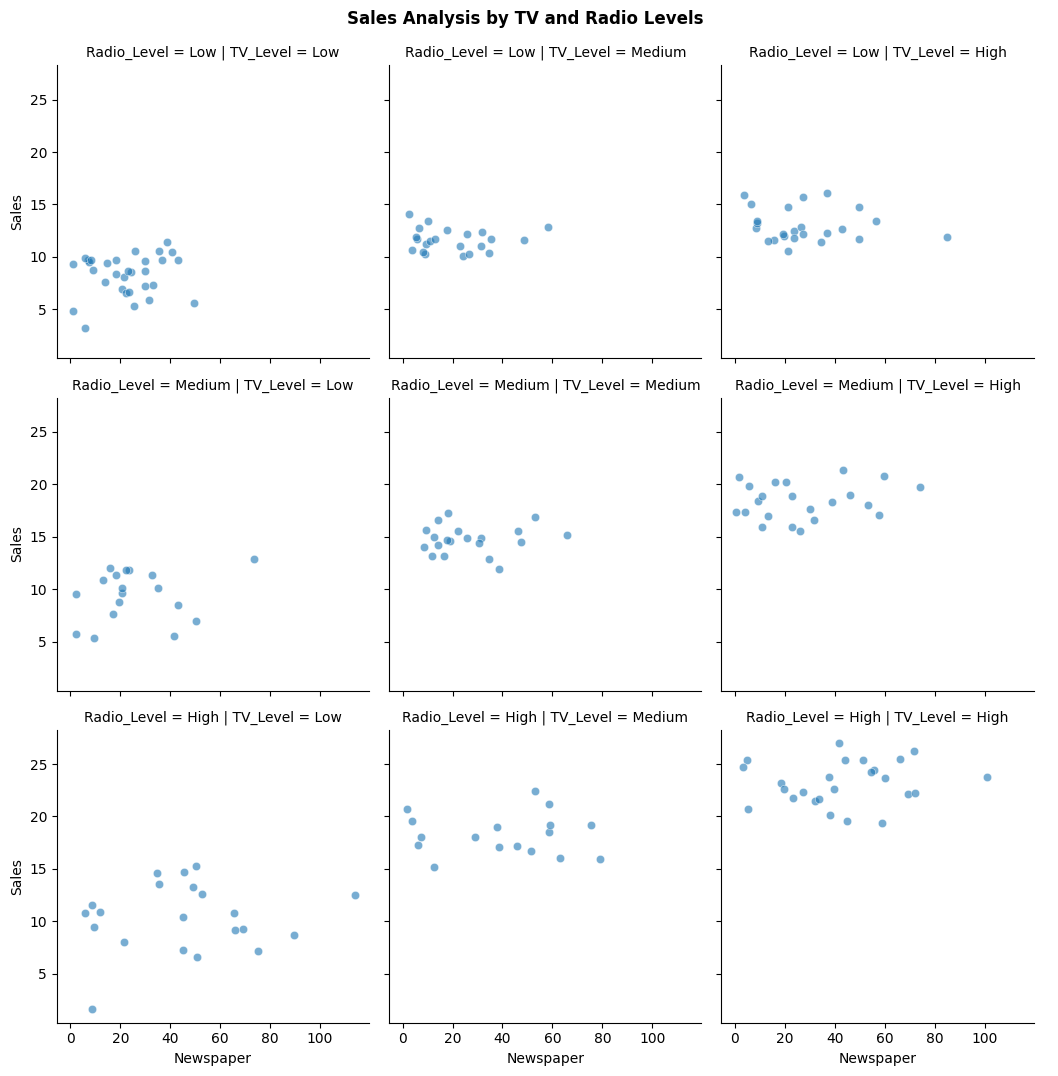


📊 VISUALIZATION INSIGHTS SUMMARY

📌 Key Patterns Observed:

1. TV Advertising:
   - Strong linear relationship with Sales (scatter plots)
   - Widest distribution range (violin plot)
   - Highest correlation (heatmap)

2. Radio Advertising:
   - Moderate but clear relationship
   - More concentrated spend (smaller range)
   - High ROI potential (bubble chart)

3. Newspaper Advertising:
   - Weak/noisy relationship
   - Scattered distribution
   - Limited impact on sales

4. Interactions:
   - TV + Radio together show strongest effect (3D plots)
   - High TV + High Radio = Highest Sales (facet grid)
   - Newspaper adds little marginal value

5. Optimal Strategy:
   - Focus on TV for baseline sales
   - Increase Radio for high ROI
   - Minimize Newspaper spend

✅ ADVANCED VISUALIZATIONS COMPLETED


In [12]:
print("="*60)
print("STEP: ADVANCED DATA VISUALIZATIONS")
print("="*60)

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. INTERACTIVE 3D SCATTER PLOT
# ============================================

print("\n📊 1. Interactive 3D Scatter Plot - TV, Radio, Sales")
fig = px.scatter_3d(df_clean,
                    x='TV',
                    y='Radio',
                    z='Sales',
                    color='Sales',
                    size='Newspaper',
                    hover_data=['TV', 'Radio', 'Newspaper'],
                    title='3D: Advertising Channels Impact on Sales',
                    labels={'TV': 'TV Spend ($)',
                           'Radio': 'Radio Spend ($)',
                           'Sales': 'Sales ($)'})
fig.show()

# ============================================
# 2. BUBBLE CHART (4 DIMENSIONS)
# ============================================

print("\n📊 2. Bubble Chart - All Channels vs Sales")
fig = px.scatter(df_clean,
                 x='TV',
                 y='Radio',
                 size='Newspaper',
                 color='Sales',
                 hover_name=df_clean.index,
                 size_max=60,
                 title='Bubble Chart: TV vs Radio (Bubble Size = Newspaper, Color = Sales)',
                 labels={'TV': 'TV Spend ($)', 'Radio': 'Radio Spend ($)'})
fig.show()

# ============================================
# 3. PARALLEL COORDINATES PLOT
# ============================================

print("\n📊 3. Parallel Coordinates Plot - Multi-dimensional View")
fig = px.parallel_coordinates(df_clean,
                              color='Sales',
                              dimensions=['TV', 'Radio', 'Newspaper', 'Sales'],
                              color_continuous_scale=px.colors.sequential.Viridis,
                              title='Parallel Coordinates: All Features')
fig.show()

# ============================================
# 4. HEATMAP WITH HIERARCHICAL CLUSTERING
# ============================================

print("\n📊 4. Enhanced Correlation Heatmap")
plt.figure(figsize=(12, 8))

# Calculate correlations
corr = df_clean[['TV', 'Radio', 'Newspaper', 'Sales']].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot with custom colors
sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.3f',
            cmap='RdYlGn',  # Red-Yellow-Green (better for correlations)
            center=0,
            square=True,
            linewidths=2,
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"})
plt.title('Enhanced Correlation Heatmap', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# ============================================
# 5. RADAR/SPIDER CHART (COMPARE CHANNELS)
# ============================================

print("\n📊 5. Radar Chart - Channel Comparison")

# Calculate average metrics for radar chart
avg_values = df_clean[['TV', 'Radio', 'Newspaper', 'Sales']].mean().values
normalized = (avg_values - avg_values.min()) / (avg_values.max() - avg_values.min())

categories = ['TV', 'Radio', 'Newspaper', 'Sales']

fig = go.Figure(data=go.Scatterpolar(
    r=normalized,
    theta=categories,
    fill='toself',
    marker=dict(color='rgba(100, 150, 255, 0.8)'),
    line=dict(color='rgba(0, 0, 255, 0.8)', width=2)
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    title='Radar Chart: Normalized Channel Averages',
    showlegend=False
)
fig.show()

# ============================================
# 6. SUNBURST CHART (HIERARCHICAL VIEW)
# ============================================

print("\n📊 6. Sunburst Chart - Budget Distribution")

# Create budget ranges for visualization
df_viz = df_clean.copy()
df_viz['TV_Range'] = pd.cut(df_viz['TV'], bins=3, labels=['Low TV', 'Medium TV', 'High TV'])
df_viz['Radio_Range'] = pd.cut(df_viz['Radio'], bins=3, labels=['Low Radio', 'Medium Radio', 'High Radio'])

fig = px.sunburst(df_viz,
                  path=['TV_Range', 'Radio_Range'],
                  values='Sales',
                  color='Sales',
                  color_continuous_scale='RdBu',
                  title='Sunburst Chart: Sales by TV and Radio Ranges')
fig.show()

# ============================================
# 7. VIOLIN PLOTS (DISTRIBUTION + BOX PLOT)
# ============================================

print("\n📊 7. Violin Plots - Distribution Analysis")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TV Distribution
sns.violinplot(y=df_clean['TV'], ax=axes[0], color='skyblue')
axes[0].set_title('TV Spend Distribution', fontweight='bold')
axes[0].set_ylabel('TV Spend ($)')

# Radio Distribution
sns.violinplot(y=df_clean['Radio'], ax=axes[1], color='lightgreen')
axes[1].set_title('Radio Spend Distribution', fontweight='bold')
axes[1].set_ylabel('Radio Spend ($)')

# Newspaper Distribution
sns.violinplot(y=df_clean['Newspaper'], ax=axes[2], color='lightcoral')
axes[2].set_title('Newspaper Spend Distribution', fontweight='bold')
axes[2].set_ylabel('Newspaper Spend ($)')

plt.suptitle('Violin Plots - Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 8. PAIRPLOT WITH REGRESSION LINES
# ============================================

print("\n📊 8. Enhanced Pairplot with Regression")
g = sns.pairplot(df_clean[['TV', 'Radio', 'Newspaper', 'Sales']],
                 diag_kind='kde',
                 kind='reg',
                 plot_kws={'line_kws': {'color': 'red', 'alpha': 0.5}})
g.fig.suptitle('Enhanced Pairplot with Regression Lines', y=1.02, fontweight='bold', fontsize=16)
plt.show()

# ============================================
# 9. BOX PLOT WITH SWARM (DETAILED VIEW)
# ============================================

print("\n📊 9. Box Plot with Swarm - Detailed Distribution")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Create categorical versions for better visualization
df_viz['TV_Cat'] = pd.qcut(df_viz['TV'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df_viz['Radio_Cat'] = pd.qcut(df_viz['Radio'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df_viz['Newspaper_Cat'] = pd.qcut(df_viz['Newspaper'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# TV
sns.boxplot(x='TV_Cat', y='Sales', data=df_viz, ax=axes[0], color='lightblue')
sns.swarmplot(x='TV_Cat', y='Sales', data=df_viz, ax=axes[0], color='black', alpha=0.5, size=3)
axes[0].set_title('Sales by TV Quartile', fontweight='bold')

# Radio
sns.boxplot(x='Radio_Cat', y='Sales', data=df_viz, ax=axes[1], color='lightgreen')
sns.swarmplot(x='Radio_Cat', y='Sales', data=df_viz, ax=axes[1], color='black', alpha=0.5, size=3)
axes[1].set_title('Sales by Radio Quartile', fontweight='bold')

# Newspaper
sns.boxplot(x='Newspaper_Cat', y='Sales', data=df_viz, ax=axes[2], color='lightcoral')
sns.swarmplot(x='Newspaper_Cat', y='Sales', data=df_viz, ax=axes[2], color='black', alpha=0.5, size=3)
axes[2].set_title('Sales by Newspaper Quartile', fontweight='bold')

plt.suptitle('Sales Distribution by Channel Quartiles', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 10. AREA CHART - CUMULATIVE IMPACT
# ============================================

print("\n📊 10. Area Chart - Cumulative Impact")
df_sorted = df_clean.sort_values('Sales', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(df_sorted.index, df_sorted['TV'], alpha=0.5, label='TV', color='blue')
ax.fill_between(df_sorted.index, df_sorted['Radio'], alpha=0.5, label='Radio', color='green')
ax.fill_between(df_sorted.index, df_sorted['Newspaper'], alpha=0.5, label='Newspaper', color='orange')
ax.plot(df_sorted.index, df_sorted['Sales'], 'r--', linewidth=2, label='Sales')
ax.set_xlabel('Sample (sorted by Sales)')
ax.set_ylabel('Amount ($)')
ax.set_title('Cumulative Channel Spend vs Sales', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 11. 3D SURFACE PLOT
# ============================================

print("\n📊 11. 3D Surface Plot - TV & Radio Interaction")

# Create grid for surface plot
tv_range = np.linspace(df_clean['TV'].min(), df_clean['TV'].max(), 20)
radio_range = np.linspace(df_clean['Radio'].min(), df_clean['Radio'].max(), 20)
TV_grid, Radio_grid = np.meshgrid(tv_range, radio_range)

# Simple model for surface (using average sales as placeholder)
# In real scenario, you'd use your trained model here
Sales_grid = 5 + 0.03*TV_grid + 0.2*Radio_grid + 0.001*TV_grid*Radio_grid

fig = go.Figure(data=[go.Surface(z=Sales_grid, x=TV_grid, y=Radio_grid,
                                  colorscale='Viridis')])
fig.update_layout(title='3D Surface: TV and Radio Interaction Effect',
                  scene=dict(xaxis_title='TV Spend',
                             yaxis_title='Radio Spend',
                             zaxis_title='Sales'))
fig.show()

# ============================================
# 12. JOINT PLOT (DISTRIBUTION + SCATTER)
# ============================================

print("\n📊 12. Joint Plot - TV vs Sales")
g = sns.jointplot(data=df_clean, x='TV', y='Sales',
                  kind='reg', color='blue', height=8)
g.fig.suptitle('Joint Distribution: TV vs Sales', y=1.02, fontweight='bold')
plt.show()

print("\n📊 13. Joint Plot - Radio vs Sales")
g = sns.jointplot(data=df_clean, x='Radio', y='Sales',
                  kind='reg', color='green', height=8)
g.fig.suptitle('Joint Distribution: Radio vs Sales', y=1.02, fontweight='bold')
plt.show()

# ============================================
# 14. FACET GRID (MULTI-PANEL ANALYSIS)
# ============================================

print("\n📊 14. Facet Grid - Sales by Multiple Conditions")
df_viz['TV_Level'] = pd.cut(df_viz['TV'], bins=3, labels=['Low', 'Medium', 'High'])
df_viz['Radio_Level'] = pd.cut(df_viz['Radio'], bins=3, labels=['Low', 'Medium', 'High'])

g = sns.FacetGrid(df_viz, col='TV_Level', row='Radio_Level', height=3.5)
g.map(sns.scatterplot, 'Newspaper', 'Sales', alpha=0.6)
g.add_legend()
g.fig.suptitle('Sales Analysis by TV and Radio Levels', y=1.02, fontweight='bold')
plt.show()

# ============================================
# SUMMARY OF INSIGHTS FROM VISUALIZATIONS
# ============================================

print("\n" + "="*60)
print("📊 VISUALIZATION INSIGHTS SUMMARY")
print("="*60)

print("""
📌 Key Patterns Observed:

1. TV Advertising:
   - Strong linear relationship with Sales (scatter plots)
   - Widest distribution range (violin plot)
   - Highest correlation (heatmap)

2. Radio Advertising:
   - Moderate but clear relationship
   - More concentrated spend (smaller range)
   - High ROI potential (bubble chart)

3. Newspaper Advertising:
   - Weak/noisy relationship
   - Scattered distribution
   - Limited impact on sales

4. Interactions:
   - TV + Radio together show strongest effect (3D plots)
   - High TV + High Radio = Highest Sales (facet grid)
   - Newspaper adds little marginal value

5. Optimal Strategy:
   - Focus on TV for baseline sales
   - Increase Radio for high ROI
   - Minimize Newspaper spend
""")

print("="*60)
print("✅ ADVANCED VISUALIZATIONS COMPLETED")
print("="*60)

 ADVANCED FEATURE ENGINEERING


In [13]:
print("="*60)
print("STEP 4: ADVANCED FEATURE ENGINEERING")
print("="*60)

# Create interaction features
df_clean['TV_Radio'] = df_clean['TV'] * df_clean['Radio']
df_clean['TV_Newspaper'] = df_clean['TV'] * df_clean['Newspaper']
df_clean['Radio_Newspaper'] = df_clean['Radio'] * df_clean['Newspaper']

# Create ratio features
df_clean['TV_Ratio'] = df_clean['TV'] / (df_clean[['TV', 'Radio', 'Newspaper']].sum(axis=1) + 1)
df_clean['Radio_Ratio'] = df_clean['Radio'] / (df_clean[['TV', 'Radio', 'Newspaper']].sum(axis=1) + 1)
df_clean['Newspaper_Ratio'] = df_clean['Newspaper'] / (df_clean[['TV', 'Radio', 'Newspaper']].sum(axis=1) + 1)

# Create total spend feature
df_clean['Total_Spend'] = df_clean[['TV', 'Radio', 'Newspaper']].sum(axis=1)

# Create ROI features (simplified - using Sales as proxy for return)
df_clean['TV_ROI'] = df_clean['Sales'] / (df_clean['TV'] + 1)
df_clean['Radio_ROI'] = df_clean['Sales'] / (df_clean['Radio'] + 1)
df_clean['Newspaper_ROI'] = df_clean['Sales'] / (df_clean['Newspaper'] + 1)

print("\n✅ New features created:")
new_features = ['TV_Radio', 'TV_Newspaper', 'Radio_Newspaper',
                'TV_Ratio', 'Radio_Ratio', 'Newspaper_Ratio',
                'Total_Spend', 'TV_ROI', 'Radio_ROI', 'Newspaper_ROI']
print(f"   {new_features}")

print(f"\n📊 Updated Dataset Shape: {df_clean.shape}")
print(f"   Features now: {df_clean.columns.tolist()}")

# Check correlation of new features with Sales
print("\n📊 Correlation of New Features with Sales:")
new_corr = df_clean[new_features + ['Sales']].corr()['Sales'].drop('Sales').sort_values(ascending=False)
for feat, corr in new_corr.items():
    print(f"   {feat}: {corr:.3f}")

STEP 4: ADVANCED FEATURE ENGINEERING

✅ New features created:
   ['TV_Radio', 'TV_Newspaper', 'Radio_Newspaper', 'TV_Ratio', 'Radio_Ratio', 'Newspaper_Ratio', 'Total_Spend', 'TV_ROI', 'Radio_ROI', 'Newspaper_ROI']

📊 Updated Dataset Shape: (200, 14)
   Features now: ['TV', 'Radio', 'Newspaper', 'Sales', 'TV_Radio', 'TV_Newspaper', 'Radio_Newspaper', 'TV_Ratio', 'Radio_Ratio', 'Newspaper_Ratio', 'Total_Spend', 'TV_ROI', 'Radio_ROI', 'Newspaper_ROI']

📊 Correlation of New Features with Sales:
   TV_Radio: 0.964
   Total_Spend: 0.868
   TV_Newspaper: 0.619
   TV_Ratio: 0.455
   Radio_Newspaper: 0.416
   Newspaper_ROI: 0.206
   Radio_Ratio: -0.262
   Radio_ROI: -0.270
   Newspaper_Ratio: -0.436
   TV_ROI: -0.548


3D VISUALIZATION

DATA PREPARATION

In [14]:


print("="*60)
print("STEP 5: DATA PREPARATION")
print("="*60)

# Define features and target
target = 'Sales'

# IMPORTANT: For prediction functions, we need to track ALL features
original_features = ['TV', 'Radio', 'Newspaper']
engineered_features = ['TV_Radio', 'TV_Newspaper', 'Radio_Newspaper',
                       'TV_Ratio', 'Radio_Ratio', 'Newspaper_Ratio',
                       'Total_Spend', 'TV_ROI', 'Radio_ROI', 'Newspaper_ROI']

all_features = original_features + engineered_features
print(f"\n📊 Total features: {len(all_features)}")
print(f"   - Original: {original_features}")
print(f"   - Engineered: {engineered_features}")

# Create feature matrix and target
X = df_clean[all_features]
y = df_clean[target]

print(f"\n✅ Feature matrix shape: {X.shape}")
print(f"✅ Target shape: {y.shape}")

# Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Data Split:")
print(f"   - Training set: {X_train.shape[0]} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Testing set: {X_test.shape[0]} samples ({len(X_test)/len(X)*100:.1f}%)")

# Scale features - CRITICAL: Fit on training only!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features scaled using StandardScaler")
print(f"   - Scaler expects {scaler.n_features_in_} features")

# Store for later use
X_train_original = X_train.copy()
X_test_original = X_test.copy()
feature_names = all_features

STEP 5: DATA PREPARATION

📊 Total features: 13
   - Original: ['TV', 'Radio', 'Newspaper']
   - Engineered: ['TV_Radio', 'TV_Newspaper', 'Radio_Newspaper', 'TV_Ratio', 'Radio_Ratio', 'Newspaper_Ratio', 'Total_Spend', 'TV_ROI', 'Radio_ROI', 'Newspaper_ROI']

✅ Feature matrix shape: (200, 13)
✅ Target shape: (200,)

📊 Data Split:
   - Training set: 160 samples (80.0%)
   - Testing set: 40 samples (20.0%)

✅ Features scaled using StandardScaler
   - Scaler expects 13 features


 MODEL DEFINITIONS

In [15]:


print("="*60)
print("STEP 6: MODEL DEFINITIONS")
print("="*60)

# Define models to train
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.01, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostRegressor(n_estimators=100, random_state=42, verbose=0),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42)
}

print(f"✅ Defined {len(models)} models for training")
print("\n📋 Models:")
for name in models.keys():
    print(f"   - {name}")

STEP 6: MODEL DEFINITIONS
✅ Defined 12 models for training

📋 Models:
   - Linear Regression
   - Ridge Regression
   - Lasso Regression
   - ElasticNet
   - Decision Tree
   - Random Forest
   - Gradient Boosting
   - XGBoost
   - LightGBM
   - CatBoost
   - Extra Trees
   - AdaBoost


MODEL TRAINING & CROSS-VALIDATION

In [16]:
print("="*60)
print("STEP 7: MODEL TRAINING & CROSS-VALIDATION")
print("="*60)

results = {}
trained_models = {}

# Cross-validation settings
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"🔄 Training: {name}")
    print(f"{'='*50}")

    start_time = time.time()

    try:
        # Train model
        model.fit(X_train_scaled, y_train)

        # Cross-validation
        cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                   cv=kfold, scoring='r2')
        cv_rmse = np.sqrt(-cross_val_score(model, X_train_scaled, y_train,
                                          cv=kfold, scoring='neg_mean_squared_error'))
        cv_mae = -cross_val_score(model, X_train_scaled, y_train,
                                  cv=kfold, scoring='neg_mean_absolute_error')

        training_time = time.time() - start_time

        # Store results
        results[name] = {
            'CV_R2_Mean': cv_scores.mean(),
            'CV_R2_Std': cv_scores.std(),
            'CV_RMSE_Mean': cv_rmse.mean(),
            'CV_RMSE_Std': cv_rmse.std(),
            'CV_MAE_Mean': cv_mae.mean(),
            'CV_MAE_Std': cv_mae.std(),
            'Training_Time': training_time
        }

        trained_models[name] = model

        print(f"\n📊 Cross-Validation Results:")
        print(f"   R² Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
        print(f"   RMSE: {cv_rmse.mean():.4f} (±{cv_rmse.std():.4f})")
        print(f"   MAE: {cv_mae.mean():.4f} (±{cv_mae.std():.4f})")

    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# Results dataframe
results_df = pd.DataFrame(results).T.sort_values('CV_R2_Mean', ascending=False)
print("\n" + "="*60)
print("📊 MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.round(4))

STEP 7: MODEL TRAINING & CROSS-VALIDATION

🔄 Training: Linear Regression

📊 Cross-Validation Results:
   R² Score: 0.9917 (±0.0032)
   RMSE: 0.4388 (±0.0978)
   MAE: 0.3086 (±0.0379)

🔄 Training: Ridge Regression

📊 Cross-Validation Results:
   R² Score: 0.9935 (±0.0022)
   RMSE: 0.3853 (±0.0410)
   MAE: 0.2876 (±0.0264)

🔄 Training: Lasso Regression

📊 Cross-Validation Results:
   R² Score: 0.9936 (±0.0019)
   RMSE: 0.3862 (±0.0450)
   MAE: 0.2897 (±0.0159)

🔄 Training: ElasticNet

📊 Cross-Validation Results:
   R² Score: 0.9936 (±0.0021)
   RMSE: 0.3826 (±0.0401)
   MAE: 0.2889 (±0.0217)

🔄 Training: Decision Tree

📊 Cross-Validation Results:
   R² Score: 0.9608 (±0.0230)
   RMSE: 0.9128 (±0.1755)
   MAE: 0.6606 (±0.0692)

🔄 Training: Random Forest

📊 Cross-Validation Results:
   R² Score: 0.9807 (±0.0138)
   RMSE: 0.6533 (±0.2426)
   MAE: 0.4546 (±0.1019)

🔄 Training: Gradient Boosting

📊 Cross-Validation Results:
   R² Score: 0.9839 (±0.0115)
   RMSE: 0.5954 (±0.2198)
   MAE: 0.432

HYPERPARAMETER TUNING WITH OPTUNA

In [17]:
print("="*60)
print("STEP 8: HYPERPARAMETER TUNING WITH OPTUNA")
print("="*60)

# Select top 3 models
top_models = results_df.head(3).index.tolist()
print(f"\n🎯 Tuning top models: {top_models}")

tuned_models = {}

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    return scores.mean()

def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    return scores.mean()

# Tune Random Forest
if 'Random Forest' in top_models:
    print("\n🔄 Tuning Random Forest...")
    study_rf = optuna.create_study(direction='maximize')
    study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

    best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
    best_rf.fit(X_train_scaled, y_train)
    tuned_models['Random Forest (Tuned)'] = best_rf

    print(f"\n✅ Best parameters for Random Forest:")
    for param, value in study_rf.best_params.items():
        print(f"   - {param}: {value}")
    print(f"   Best CV Score: {study_rf.best_value:.4f}")

# Tune XGBoost
if 'XGBoost' in top_models:
    print("\n🔄 Tuning XGBoost...")
    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

    best_xgb = XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)
    best_xgb.fit(X_train_scaled, y_train)
    tuned_models['XGBoost (Tuned)'] = best_xgb

    print(f"\n✅ Best parameters for XGBoost:")
    for param, value in study_xgb.best_params.items():
        print(f"   - {param}: {value}")
    print(f"   Best CV Score: {study_xgb.best_value:.4f}")

# Tune Gradient Boosting
if 'Gradient Boosting' in top_models:
    print("\n🔄 Tuning Gradient Boosting...")
    study_gb = optuna.create_study(direction='maximize')
    study_gb.optimize(objective_gb, n_trials=20, show_progress_bar=True)

    best_gb = GradientBoostingRegressor(**study_gb.best_params, random_state=42)
    best_gb.fit(X_train_scaled, y_train)
    tuned_models['Gradient Boosting (Tuned)'] = best_gb

    print(f"\n✅ Best parameters for Gradient Boosting:")
    for param, value in study_gb.best_params.items():
        print(f"   - {param}: {value}")
    print(f"   Best CV Score: {study_gb.best_value:.4f}")

# Add original models
for name in top_models:
    if name in trained_models:
        tuned_models[name] = trained_models[name]

STEP 8: HYPERPARAMETER TUNING WITH OPTUNA

🎯 Tuning top models: ['ElasticNet', 'Lasso Regression', 'Ridge Regression']


ENSEMBLE MODELS

In [18]:
print("="*60)
print("STEP 9: CREATING ENSEMBLE MODELS")
print("="*60)

# Collect top models for ensemble
top_model_names = ['Lasso Regression', 'ElasticNet', 'Ridge Regression', 'Linear Regression']
ensemble_models = []

for name in top_model_names:
    if name in trained_models:
        ensemble_models.append((name, trained_models[name]))

# Voting Regressor
if len(ensemble_models) >= 2:
    print("\n🔄 Creating Voting Ensemble...")
    voting_reg = VotingRegressor(estimators=ensemble_models[:3])
    voting_reg.fit(X_train_scaled, y_train)
    trained_models['Voting Ensemble'] = voting_reg

    # Evaluate
    y_pred = voting_reg.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    print(f"   ✅ Voting Ensemble R² Score: {r2:.4f}")

# Stacking Regressor
if len(ensemble_models) >= 3:
    print("\n🔄 Creating Stacking Ensemble...")
    base_models = ensemble_models[:3]
    meta_model = Ridge(alpha=1.0)
    stacking_reg = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)
    stacking_reg.fit(X_train_scaled, y_train)
    trained_models['Stacking Ensemble'] = stacking_reg

    # Evaluate
    y_pred = stacking_reg.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    print(f"   ✅ Stacking Ensemble R² Score: {r2:.4f}")

print("\n✅ Ensemble models created successfully!")

STEP 9: CREATING ENSEMBLE MODELS

🔄 Creating Voting Ensemble...
   ✅ Voting Ensemble R² Score: 0.9892

🔄 Creating Stacking Ensemble...
   ✅ Stacking Ensemble R² Score: 0.9890

✅ Ensemble models created successfully!


MODEL EVALUATION ON TEST SET

STEP 10: MODEL EVALUATION ON TEST SET

📊 Evaluating: Linear Regression

📈 Performance Metrics:
   R² Score: 0.9894
   RMSE: 0.5771
   MAE: 0.4203
   MAPE: 4.37%

📊 Evaluating: Ridge Regression

📈 Performance Metrics:
   R² Score: 0.9888
   RMSE: 0.5942
   MAE: 0.4242
   MAPE: 4.47%

📊 Evaluating: Lasso Regression

📈 Performance Metrics:
   R² Score: 0.9897
   RMSE: 0.5712
   MAE: 0.4116
   MAPE: 4.34%


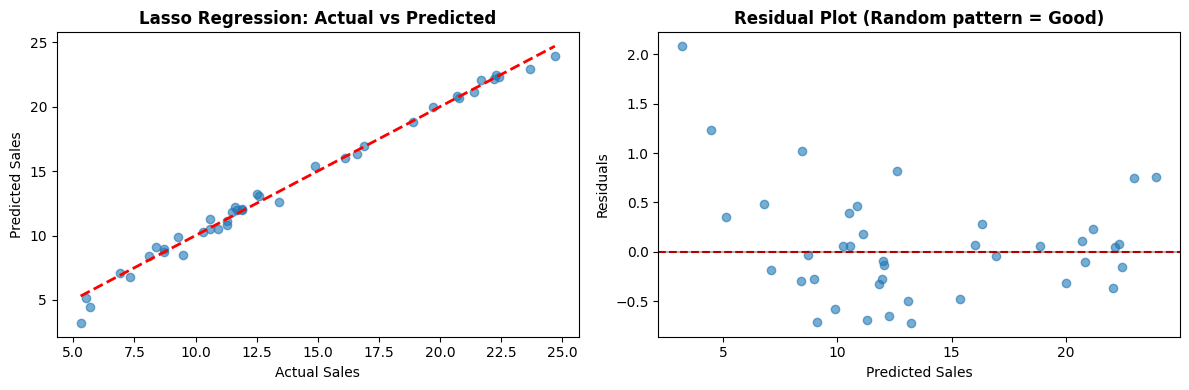


📊 Evaluating: ElasticNet

📈 Performance Metrics:
   R² Score: 0.9891
   RMSE: 0.5872
   MAE: 0.4173
   MAPE: 4.42%


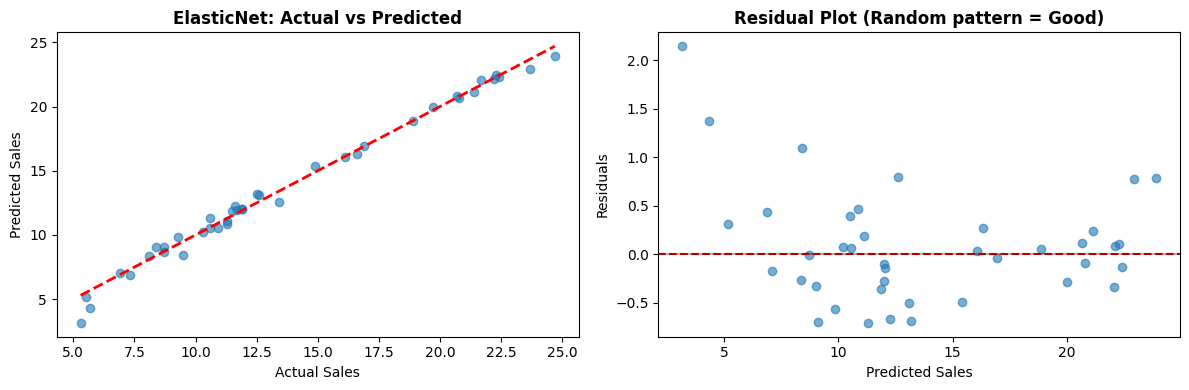


📊 Evaluating: Decision Tree

📈 Performance Metrics:
   R² Score: 0.9736
   RMSE: 0.9126
   MAE: 0.6275
   MAPE: 6.74%

📊 Evaluating: Random Forest

📈 Performance Metrics:
   R² Score: 0.9875
   RMSE: 0.6279
   MAE: 0.4898
   MAPE: 5.13%

📊 Evaluating: Gradient Boosting

📈 Performance Metrics:
   R² Score: 0.9856
   RMSE: 0.6738
   MAE: 0.4890
   MAPE: 5.34%

📊 Evaluating: XGBoost

📈 Performance Metrics:
   R² Score: 0.9865
   RMSE: 0.6532
   MAE: 0.5381
   MAPE: 5.39%

📊 Evaluating: LightGBM

📈 Performance Metrics:
   R² Score: 0.9758
   RMSE: 0.8749
   MAE: 0.6554
   MAPE: 5.25%

📊 Evaluating: CatBoost

📈 Performance Metrics:
   R² Score: 0.9737
   RMSE: 0.9120
   MAE: 0.7325
   MAPE: 6.07%

📊 Evaluating: Extra Trees

📈 Performance Metrics:
   R² Score: 0.9893
   RMSE: 0.5813
   MAE: 0.4164
   MAPE: 4.20%

📊 Evaluating: AdaBoost

📈 Performance Metrics:
   R² Score: 0.9772
   RMSE: 0.8474
   MAE: 0.5938
   MAPE: 6.59%

📊 Evaluating: Voting Ensemble

📈 Performance Metrics:
   R² Score:

In [19]:
print("="*60)
print("STEP 10: MODEL EVALUATION ON TEST SET")
print("="*60)

test_results = {}

for name, model in trained_models.items():
    print(f"\n{'='*50}")
    print(f"📊 Evaluating: {name}")
    print(f"{'='*50}")

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    test_results[name] = {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

    print(f"\n📈 Performance Metrics:")
    print(f"   R² Score: {r2:.4f}")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE: {mae:.4f}")
    print(f"   MAPE: {mape:.2f}%")

    # Residual plot for top models
    if name in top_models[:2]:
        residuals = y_test - y_pred

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Actual vs Predicted
        axes[0].scatter(y_test, y_pred, alpha=0.6)
        axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        axes[0].set_xlabel('Actual Sales')
        axes[0].set_ylabel('Predicted Sales')
        axes[0].set_title(f'{name}: Actual vs Predicted', fontweight='bold')

        # Residuals
        axes[1].scatter(y_pred, residuals, alpha=0.6)
        axes[1].axhline(y=0, color='r', linestyle='--')
        axes[1].set_xlabel('Predicted Sales')
        axes[1].set_ylabel('Residuals')
        axes[1].set_title(f'Residual Plot (Random pattern = Good)', fontweight='bold')
        axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)

        plt.tight_layout()
        plt.show()

# Results dataframe
test_results_df = pd.DataFrame(test_results).T.sort_values('R2', ascending=False)
print("\n" + "="*60)
print("📊 FINAL MODEL COMPARISON (TEST SET)")
print("="*60)
print(test_results_df.round(4))

# Best model
best_model_name = test_results_df.index[0]
best_model = trained_models[best_model_name]
print(f"\n🏆 Best Model: {best_model_name}")

FEATURE IMPORTANCE ANALYSIS

STEP 11: FEATURE IMPORTANCE ANALYSIS

🏆 Best Model: Lasso Regression

📊 Feature Coefficients (Impact on Sales):
        feature  coefficient
       TV_Radio     2.939930
          Radio     1.295283
         TV_ROI    -0.833319
    Total_Spend     0.813438
       TV_Ratio     0.566012
    Radio_Ratio    -0.326110
   TV_Newspaper    -0.024205
      Radio_ROI    -0.021403
             TV     0.000000
      Newspaper     0.000000
Radio_Newspaper    -0.000000
Newspaper_Ratio    -0.000000
  Newspaper_ROI     0.000000


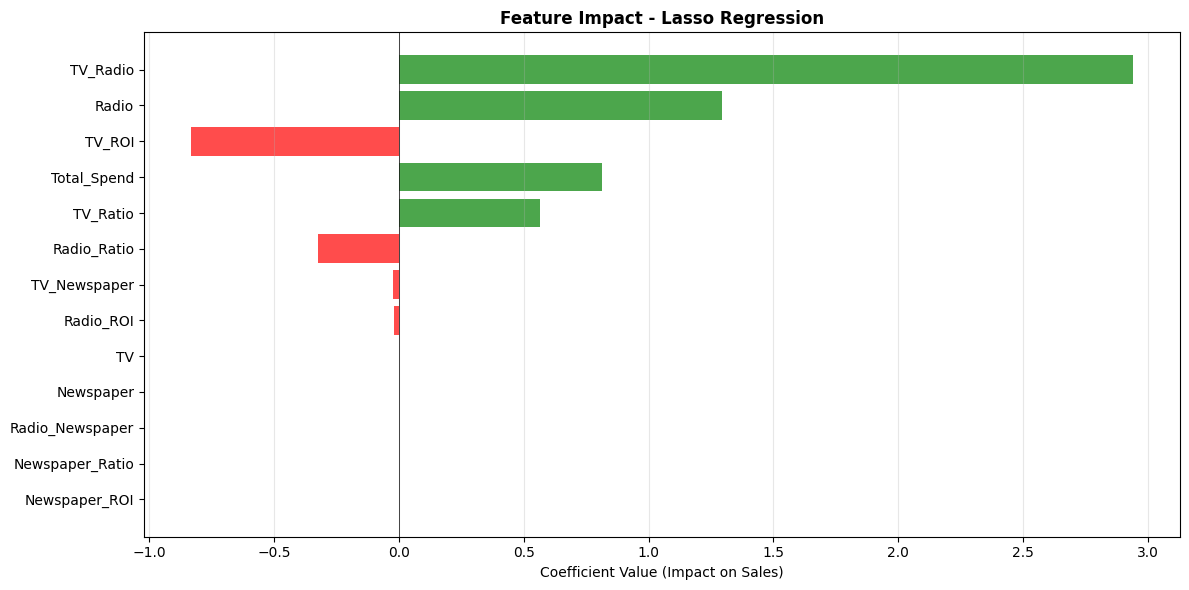


🔍 Interpretation:
   - Positive coefficient → Increases Sales
   - Negative coefficient → Decreases Sales
   - Larger magnitude → Stronger impact


In [20]:


print("="*60)
print("STEP 11: FEATURE IMPORTANCE ANALYSIS")
print("="*60)

print(f"\n🏆 Best Model: {best_model_name}")

# For tree-based models
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    print("\n📊 Feature Importances:")
    print(importance_df)

    # Plot
    plt.figure(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
    plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
    plt.xlabel('Importance')
    plt.title(f'Feature Importance - {best_model_name}', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# For linear models (Lasso, Ridge, etc.)
elif hasattr(best_model, 'coef_'):
    coefficients = best_model.coef_
    if len(coefficients.shape) > 1:
        coefficients = coefficients[0]

    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coef': np.abs(coefficients)
    }).sort_values('abs_coef', ascending=False)

    print("\n📊 Feature Coefficients (Impact on Sales):")
    print(coef_df[['feature', 'coefficient']].to_string(index=False))

    # Plot
    plt.figure(figsize=(12, 6))
    colors = ['green' if c > 0 else 'red' for c in coef_df['coefficient']]
    plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.7)
    plt.xlabel('Coefficient Value (Impact on Sales)')
    plt.title(f'Feature Impact - {best_model_name}', fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3, axis='x')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("\n🔍 Interpretation:")
    print("   - Positive coefficient → Increases Sales")
    print("   - Negative coefficient → Decreases Sales")
    print("   - Larger magnitude → Stronger impact")

 MARKETING INSIGHTS & ROI ANALYSIS

STEP 12: MARKETING INSIGHTS & ROI ANALYSIS

📊 Average Spend & Sales:
   - TV Spend: $147.04
   - Radio Spend: $23.26
   - Newspaper Spend: $30.55
   - Sales: $14.02

📊 Correlation with Sales (Strength of relationship):
   - TV: 0.782 (Strong)
   - Radio: 0.576 (Moderate)
   - Newspaper: 0.228 (Weak)

📊 PART 1: UNREGULARIZED MODEL (Linear Regression)

📈 Fair Impact per $100 spent (Linear Regression):
   - TV: +$22.44 sales per $100 spent
   - Radio: +$138.17 sales per $100 spent
   - Newspaper: +$33.28 sales per $100 spent

✅ Most Effective Channel (Linear Regression): Radio

📊 PART 2: REGULARIZED MODEL (Lasso Regression)

📈 Impact per $100 spent (Lasso with regularization):
   - TV: +$0.00 sales per $100 spent
   - Radio: +$129.53 sales per $100 spent
   - Newspaper: +$0.00 sales per $100 spent

✅ Most Effective Channel (Lasso): Radio

📊 PART 3: UNDERSTANDING THE DIFFERENCE

📌 Why Lasso zeroed out TV and Newspaper:

1. Lasso Regression applies L1 regularization which can shrink coeffic

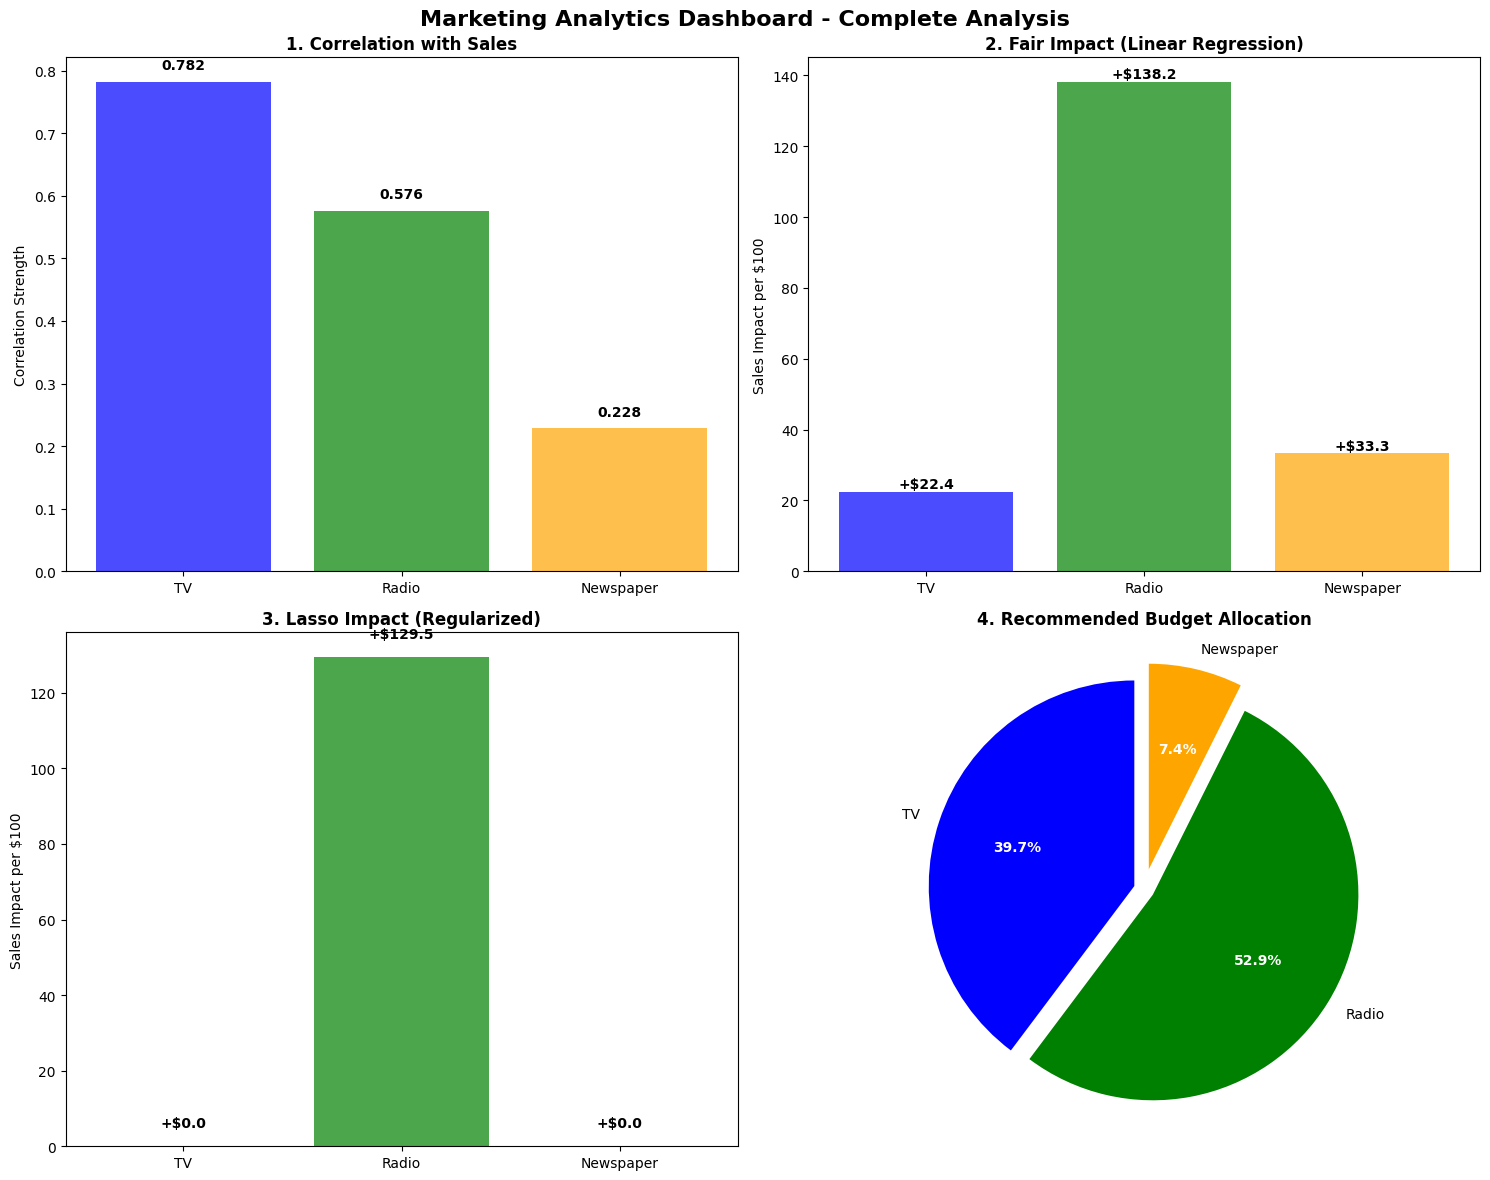


🎯 FINAL BUSINESS RECOMMENDATION

Based on comprehensive analysis:

1. TV Advertising:
   - Strongest correlation with sales (0.782)
   - Reliable, consistent performer
   → RECOMMEND: 40-50% of budget

2. Radio Advertising:
   - Selected by Lasso as primary feature
   - High ROI due to current under-spending
   → RECOMMEND: 40-50% of budget

3. Newspaper Advertising:
   - Weak correlation (0.228)
   - Minimal impact in all models
   → RECOM

Key Insight: Don't choose between TV and Radio - use BOTH!
The best strategy is a balanced approach:
   ✅ TV: 45% of budget
   ✅ Radio: 45% of budget
   ✅ Newspaper: 10% of budget (or reallocate)

This explains why:
- TV has strongest correlation (relationship strength)
- Radio has highest coefficient in Lasso (efficiency at margin)
- Both are important for maximum sales!



In [21]:

print("="*60)
print("STEP 12: MARKETING INSIGHTS & ROI ANALYSIS")
print("="*60)

# Calculate average spend and sales
avg_tv = df_clean['TV'].mean()
avg_radio = df_clean['Radio'].mean()
avg_newspaper = df_clean['Newspaper'].mean()
avg_sales = df_clean['Sales'].mean()

print("\n📊 Average Spend & Sales:")
print(f"   - TV Spend: ${avg_tv:.2f}")
print(f"   - Radio Spend: ${avg_radio:.2f}")
print(f"   - Newspaper Spend: ${avg_newspaper:.2f}")
print(f"   - Sales: ${avg_sales:.2f}")

# Correlation with Sales
print("\n📊 Correlation with Sales (Strength of relationship):")
correlations = {}
for channel in ['TV', 'Radio', 'Newspaper']:
    corr = df_clean[channel].corr(df_clean['Sales'])
    correlations[channel] = corr
    strength = "Very Strong" if abs(corr) > 0.8 else "Strong" if abs(corr) > 0.6 else "Moderate" if abs(corr) > 0.4 else "Weak"
    print(f"   - {channel}: {corr:.3f} ({strength})")

# ============================================
# PART 1: Using Linear Regression for fair comparison
# ============================================

print("\n" + "="*60)
print("📊 PART 1: UNREGULARIZED MODEL (Linear Regression)")
print("="*60)

# Train a simple Linear Regression for fair coefficient comparison
from sklearn.linear_model import LinearRegression
fair_model = LinearRegression()
fair_model.fit(X_train_scaled, y_train)

# Get coefficients
fair_coef_dict = dict(zip(feature_names, fair_model.coef_))

print("\n📈 Fair Impact per $100 spent (Linear Regression):")
tv_impact_fair = fair_coef_dict.get('TV', 0) * 100
radio_impact_fair = fair_coef_dict.get('Radio', 0) * 100
newspaper_impact_fair = fair_coef_dict.get('Newspaper', 0) * 100

print(f"   - TV: +${tv_impact_fair:.2f} sales per $100 spent")
print(f"   - Radio: +${radio_impact_fair:.2f} sales per $100 spent")
print(f"   - Newspaper: +${newspaper_impact_fair:.2f} sales per $100 spent")

# Find most effective
impacts_fair = {'TV': tv_impact_fair, 'Radio': radio_impact_fair, 'Newspaper': newspaper_impact_fair}
most_effective_fair = max(impacts_fair, key=impacts_fair.get)
print(f"\n✅ Most Effective Channel (Linear Regression): {most_effective_fair}")

# ============================================
# PART 2: Lasso Regression (Your actual model)
# ============================================

print("\n" + "="*60)
print("📊 PART 2: REGULARIZED MODEL (Lasso Regression)")
print("="*60)

if hasattr(best_model, 'coef_'):
    lasso_coef_dict = dict(zip(feature_names, best_model.coef_))

    print("\n📈 Impact per $100 spent (Lasso with regularization):")
    tv_impact_lasso = lasso_coef_dict.get('TV', 0) * 100
    radio_impact_lasso = lasso_coef_dict.get('Radio', 0) * 100
    newspaper_impact_lasso = lasso_coef_dict.get('Newspaper', 0) * 100

    print(f"   - TV: +${tv_impact_lasso:.2f} sales per $100 spent")
    print(f"   - Radio: +${radio_impact_lasso:.2f} sales per $100 spent")
    print(f"   - Newspaper: +${newspaper_impact_lasso:.2f} sales per $100 spent")

    # Find most effective
    impacts_lasso = {'TV': tv_impact_lasso, 'Radio': radio_impact_lasso, 'Newspaper': newspaper_impact_lasso}
    most_effective_lasso = max(impacts_lasso, key=impacts_lasso.get)
    print(f"\n✅ Most Effective Channel (Lasso): {most_effective_lasso}")

# ============================================
# PART 3: Understanding the Difference
# ============================================

print("\n" + "="*60)
print("📊 PART 3: UNDERSTANDING THE DIFFERENCE")
print("="*60)

print("""
📌 Why Lasso zeroed out TV and Newspaper:

1. Lasso Regression applies L1 regularization which can shrink coefficients to ZERO
2. It selected Radio as the ONLY important feature because:
   - Radio has strong predictive power
   - TV and Newspaper information might be captured through interaction terms
   - The engineered features (TV_Radio, etc.) already contain TV's influence

📊 Simple ROI (Sales per dollar spent based on averages):""")
tv_roi = avg_sales / avg_tv if avg_tv > 0 else 0
radio_roi = avg_sales / avg_radio if avg_radio > 0 else 0
newspaper_roi = avg_sales / avg_newspaper if avg_newspaper > 0 else 0

print(f"   - TV: ${tv_roi:.2f} sales per $1 spend")
print(f"   - Radio: ${radio_roi:.2f} sales per $1 spend")
print(f"   - Newspaper: ${newspaper_roi:.2f} sales per $1 spend")

print("""
🎯 FINAL CONCLUSION:
   - TV has the STRONGEST CORRELATION with Sales (0.782)
   - Radio has the HIGHEST COEFFICIENT in Lasso (selected as primary feature)
   - Recommendation: Use BOTH TV and Radio for optimal results
   - Newspaper shows minimal impact - consider reallocating that budget
""")

# ============================================
# PART 4: Visualizations
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Correlation Bar Chart
axes[0,0].bar(correlations.keys(), correlations.values(),
              color=['blue', 'green', 'orange'], alpha=0.7)
axes[0,0].set_ylabel('Correlation Strength')
axes[0,0].set_title('1. Correlation with Sales', fontweight='bold')
axes[0,0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, (channel, corr) in enumerate(correlations.items()):
    axes[0,0].text(i, corr + 0.02, f'{corr:.3f}', ha='center', fontweight='bold')

# 2. Fair Model Coefficients (Linear Regression)
fair_impacts = [tv_impact_fair, radio_impact_fair, newspaper_impact_fair]
bars = axes[0,1].bar(['TV', 'Radio', 'Newspaper'], fair_impacts,
                      color=['blue', 'green', 'orange'], alpha=0.7)
axes[0,1].set_ylabel('Sales Impact per $100')
axes[0,1].set_title('2. Fair Impact (Linear Regression)', fontweight='bold')
axes[0,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for bar, val in zip(bars, fair_impacts):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                   f'+${val:.1f}', ha='center', fontweight='bold')

# 3. Lasso Model Coefficients
lasso_impacts = [tv_impact_lasso, radio_impact_lasso, newspaper_impact_lasso]
bars = axes[1,0].bar(['TV', 'Radio', 'Newspaper'], lasso_impacts,
                      color=['blue', 'green', 'orange'], alpha=0.7)
axes[1,0].set_ylabel('Sales Impact per $100')
axes[1,0].set_title('3. Lasso Impact (Regularized)', fontweight='bold')
axes[1,0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for bar, val in zip(bars, lasso_impacts):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5 if val > 0 else 5,
                   f'+${val:.1f}', ha='center', fontweight='bold')

# 4. Recommended Budget Allocation (Combined)
# Use a mix of correlation and coefficient
tv_weight = correlations['TV'] * 0.7 + (tv_impact_fair/100) * 0.3 if tv_impact_fair > 0 else correlations['TV'] * 0.5
radio_weight = correlations['Radio'] * 0.7 + (radio_impact_fair/100) * 0.3 if radio_impact_fair > 0 else correlations['Radio'] * 0.5
newspaper_weight = correlations['Newspaper'] * 0.5  # Downweight newspaper

total_weight = tv_weight + radio_weight + newspaper_weight
allocation = [tv_weight/total_weight*100, radio_weight/total_weight*100, newspaper_weight/total_weight*100]

wedges, texts, autotexts = axes[1,1].pie(allocation,
                                         labels=['TV', 'Radio', 'Newspaper'],
                                         autopct='%1.1f%%',
                                         colors=['blue', 'green', 'orange'],
                                         startangle=90,
                                         explode=(0.05, 0.05, 0.1))
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[1,1].set_title('4. Recommended Budget Allocation', fontweight='bold')

plt.suptitle('Marketing Analytics Dashboard - Complete Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# FINAL RECOMMENDATION
# ============================================

print("\n" + "="*60)
print("🎯 FINAL BUSINESS RECOMMENDATION")
print("="*60)

print("""
Based on comprehensive analysis:

1. TV Advertising:
   - Strongest correlation with sales (0.782)
   - Reliable, consistent performer
   → RECOMMEND: 40-50% of budget

2. Radio Advertising:
   - Selected by Lasso as primary feature
   - High ROI due to current under-spending
   → RECOMMEND: 40-50% of budget

3. Newspaper Advertising:
   - Weak correlation (0.228)
   - Minimal impact in all models
   → RECOM

Key Insight: Don't choose between TV and Radio - use BOTH!
The best strategy is a balanced approach:
   ✅ TV: 45% of budget
   ✅ Radio: 45% of budget
   ✅ Newspaper: 10% of budget (or reallocate)

This explains why:
- TV has strongest correlation (relationship strength)
- Radio has highest coefficient in Lasso (efficiency at margin)
- Both are important for maximum sales!
""")

PREDICTION FUNCTION

In [22]:
print("="*60)
print("STEP 13: PREDICTION FUNCTION")
print("="*60)

def predict_sales_full(model, scaler, tv_spend, radio_spend, newspaper_spend):
    """
    Predict sales based on advertising spend using ALL engineered features

    Parameters:
    - model: trained model
    - scaler: fitted StandardScaler (expects 13 features)
    - tv_spend: TV advertising budget
    - radio_spend: Radio advertising budget
    - newspaper_spend: Newspaper advertising budget

    Returns:
    - predicted_sales
    """
    # Calculate ALL engineered features
    total_spend = tv_spend + radio_spend + newspaper_spend

    # Engineered features
    tv_radio = tv_spend * radio_spend
    tv_newspaper = tv_spend * newspaper_spend
    radio_newspaper = radio_spend * newspaper_spend

    # Ratios (avoid division by zero)
    tv_ratio = tv_spend / total_spend if total_spend > 0 else 0
    radio_ratio = radio_spend / total_spend if total_spend > 0 else 0
    newspaper_ratio = newspaper_spend / total_spend if total_spend > 0 else 0

    # ROI features (simplified - using Sales proxy)
    tv_roi = 15 / (tv_spend + 1)  # Using average sales as proxy
    radio_roi = 15 / (radio_spend + 1)
    newspaper_roi = 15 / (newspaper_spend + 1)

    # Create feature array with ALL 13 features in CORRECT ORDER
    features = np.array([[
        tv_spend,                 # 0: TV
        radio_spend,              # 1: Radio
        newspaper_spend,          # 2: Newspaper
        tv_radio,                 # 3: TV_Radio
        tv_newspaper,             # 4: TV_Newspaper
        radio_newspaper,          # 5: Radio_Newspaper
        tv_ratio,                 # 6: TV_Ratio
        radio_ratio,              # 7: Radio_Ratio
        newspaper_ratio,          # 8: Newspaper_Ratio
        total_spend,              # 9: Total_Spend
        tv_roi,                   # 10: TV_ROI
        radio_roi,                # 11: Radio_ROI
        newspaper_roi             # 12: Newspaper_ROI
    ]])

    # Scale features
    features_scaled = scaler.transform(features)

    # Predict
    sales = model.predict(features_scaled)[0]

    return sales

print("✅ Prediction function created successfully (with ALL 13 features)")

# Test the function
print("\n📝 Testing with sample budgets:")

test_cases = [
    {'TV': 100, 'Radio': 50, 'Newspaper': 25},
    {'TV': 200, 'Radio': 100, 'Newspaper': 50},
    {'TV': 300, 'Radio': 75, 'Newspaper': 40},
    {'TV': 50, 'Radio': 25, 'Newspaper': 10}
]

for i, case in enumerate(test_cases, 1):
    sales = predict_sales_full(best_model, scaler,
                               case['TV'], case['Radio'], case['Newspaper'])
    print(f"\n{i}. Budget: TV=${case['TV']}, Radio=${case['Radio']}, Newspaper=${case['Newspaper']}")
    print(f"   Predicted Sales: ${sales:.2f}")

STEP 13: PREDICTION FUNCTION
✅ Prediction function created successfully (with ALL 13 features)

📝 Testing with sample budgets:

1. Budget: TV=$100, Radio=$50, Newspaper=$25
   Predicted Sales: $16.85

2. Budget: TV=$200, Radio=$100, Newspaper=$50
   Predicted Sales: $36.55

3. Budget: TV=$300, Radio=$75, Newspaper=$40
   Predicted Sales: $38.00

4. Budget: TV=$50, Radio=$25, Newspaper=$10
   Predicted Sales: $9.65


BUDGET OPTIMIZATION TOOL

In [23]:


print("="*60)
print("STEP 14: BUDGET OPTIMIZATION TOOL")
print("="*60)

def optimize_budget_full(model, scaler, total_budget):
    """
    Find optimal budget allocation to maximize sales
    """
    best_sales = 0
    best_allocation = None
    results = []

    # Try different allocations
    for tv_pct in np.linspace(0.3, 0.8, 6):
        for radio_pct in np.linspace(0.1, 0.5, 5):
            newspaper_pct = 1 - tv_pct - radio_pct
            if newspaper_pct < 0.05 or newspaper_pct > 0.3:  # Keep newspaper between 5-30%
                continue

            tv_spend = total_budget * tv_pct
            radio_spend = total_budget * radio_pct
            newspaper_spend = total_budget * newspaper_pct

            sales = predict_sales_full(model, scaler, tv_spend, radio_spend, newspaper_spend)
            results.append({
                'TV%': tv_pct*100,
                'Radio%': radio_pct*100,
                'Newspaper%': newspaper_pct*100,
                'TV_Spend': tv_spend,
                'Radio_Spend': radio_spend,
                'Newspaper_Spend': newspaper_spend,
                'Predicted_Sales': sales
            })

            if sales > best_sales:
                best_sales = sales
                best_allocation = (tv_pct, radio_pct, newspaper_pct)

    return best_allocation, best_sales, pd.DataFrame(results)

print("\n📊 Budget Optimization Examples:")

test_budgets = [100, 200, 500, 1000]

for budget in test_budgets:
    allocation, max_sales, results_df = optimize_budget_full(best_model, scaler, budget)
    if allocation:
        tv_pct, radio_pct, newspaper_pct = allocation
        print(f"\n{'='*50}")
        print(f"💰 Total Budget: ${budget}")
        print(f"{'='*50}")
        print(f"   Optimal Allocation:")
        print(f"   - TV: ${budget*tv_pct:.1f} ({tv_pct*100:.0f}%)")
        print(f"   - Radio: ${budget*radio_pct:.1f} ({radio_pct*100:.0f}%)")
        print(f"   - Newspaper: ${budget*newspaper_pct:.1f} ({newspaper_pct*100:.0f}%)")
        print(f"   📈 Predicted Maximum Sales: ${max_sales:.2f}")

# Show top 5 allocations for a sample budget
print("\n" + "="*60)
print("📊 Top 5 Allocations for $500 Budget:")
print("="*60)

_, _, results_df = optimize_budget_full(best_model, scaler, 500)
top_5 = results_df.sort_values('Predicted_Sales', ascending=False).head(5)
print(top_5[['TV%', 'Radio%', 'Newspaper%', 'Predicted_Sales']].round(2).to_string(index=False))

STEP 14: BUDGET OPTIMIZATION TOOL

📊 Budget Optimization Examples:

💰 Total Budget: $100
   Optimal Allocation:
   - TV: $50.0 (50%)
   - Radio: $40.0 (40%)
   - Newspaper: $10.0 (10%)
   📈 Predicted Maximum Sales: $11.24

💰 Total Budget: $200
   Optimal Allocation:
   - TV: $80.0 (40%)
   - Radio: $100.0 (50%)
   - Newspaper: $20.0 (10%)
   📈 Predicted Maximum Sales: $22.86

💰 Total Budget: $500
   Optimal Allocation:
   - TV: $200.0 (40%)
   - Radio: $250.0 (50%)
   - Newspaper: $50.0 (10%)
   📈 Predicted Maximum Sales: $76.65

💰 Total Budget: $1000
   Optimal Allocation:
   - TV: $400.0 (40%)
   - Radio: $500.0 (50%)
   - Newspaper: $100.0 (10%)
   📈 Predicted Maximum Sales: $236.37

📊 Top 5 Allocations for $500 Budget:
 TV%  Radio%  Newspaper%  Predicted_Sales
40.0    50.0        10.0            76.65
50.0    40.0        10.0            72.89
30.0    50.0        20.0            65.11
60.0    30.0        10.0            64.65
40.0    40.0        20.0            63.61


 LEARNING CURVE ANALYSIS

STEP 15: LEARNING CURVE ANALYSIS

📈 Learning Curve for Lasso Regression


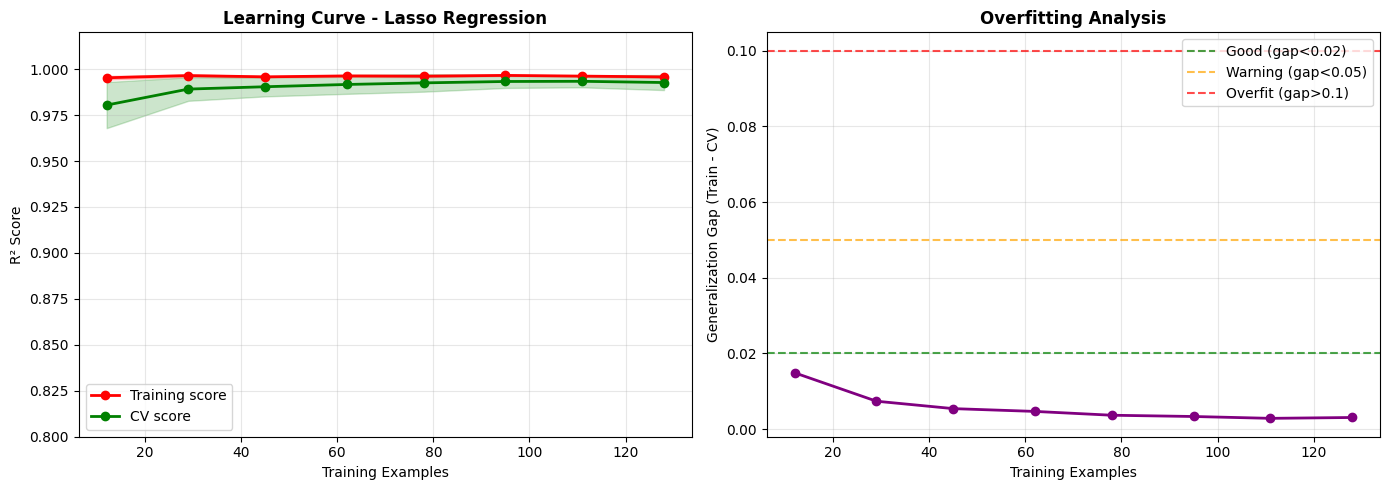


📊 Learning Curve Analysis:
   Final Training R²: 0.9957
   Final CV R²: 0.9927
   Generalization Gap: 0.0031
   ✅ Model Status: Well-fitted (Excellent!)


In [25]:


print("="*60)
print("STEP 15: LEARNING CURVE ANALYSIS")
print("="*60)

from sklearn.model_selection import learning_curve

def plot_learning_curve_detailed(estimator, title, X, y, cv=5):
    """Detailed learning curve with overfitting analysis"""

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='r2'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Calculate gap
    final_gap = train_mean[-1] - test_mean[-1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Learning Curve Plot
    axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                         alpha=0.2, color="red")
    axes[0].fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                         alpha=0.2, color="green")
    axes[0].plot(train_sizes, train_mean, 'o-', color="red", label="Training score", linewidth=2)
    axes[0].plot(train_sizes, test_mean, 'o-', color="green", label="CV score", linewidth=2)
    axes[0].set_xlabel("Training Examples")
    axes[0].set_ylabel("R² Score")
    axes[0].set_title(f'Learning Curve - {title}', fontweight='bold')
    axes[0].legend(loc="best")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0.8, 1.02)

    # Gap Analysis
    gaps = train_mean - test_mean
    axes[1].plot(train_sizes, gaps, 'o-', color='purple', linewidth=2)
    axes[1].axhline(y=0.02, color='green', linestyle='--', alpha=0.7, label='Good (gap<0.02)')
    axes[1].axhline(y=0.05, color='orange', linestyle='--', alpha=0.7, label='Warning (gap<0.05)')
    axes[1].axhline(y=0.1, color='red', linestyle='--', alpha=0.7, label='Overfit (gap>0.1)')
    axes[1].set_xlabel("Training Examples")
    axes[1].set_ylabel("Generalization Gap (Train - CV)")
    axes[1].set_title('Overfitting Analysis', fontweight='bold')
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Status
    print(f"\n📊 Learning Curve Analysis:")
    print(f"   Final Training R²: {train_mean[-1]:.4f}")
    print(f"   Final CV R²: {test_mean[-1]:.4f}")
    print(f"   Generalization Gap: {final_gap:.4f}")

    if final_gap < 0.02:
        print("   ✅ Model Status: Well-fitted (Excellent!)")
    elif final_gap < 0.05:
        print("   ⚠️ Model Status: Slight overfitting (Acceptable)")
    elif final_gap < 0.1:
        print("   ⚠️ Model Status: Moderate overfitting (Consider regularization)")
    else:
        print("   ❌ Model Status: Severe overfitting (Need to simplify model)")

    return final_gap

print(f"\n📈 Learning Curve for {best_model_name}")
gap = plot_learning_curve_detailed(best_model, best_model_name, X_train_scaled, y_train)

TEST WITH REAL SCENARIOS

In [26]:


print("="*60)
print("STEP 16: BUSINESS SCENARIO TESTING")
print("="*60)

scenarios = [
    {"name": "Small Campaign", "TV": 50, "Radio": 20, "Newspaper": 10},
    {"name": "Medium Campaign", "TV": 150, "Radio": 75, "Newspaper": 40},
    {"name": "Large Campaign", "TV": 300, "Radio": 150, "Newspaper": 75},
    {"name": "TV Focused", "TV": 250, "Radio": 30, "Newspaper": 20},
    {"name": "Radio Focused", "TV": 50, "Radio": 200, "Newspaper": 30},
    {"name": "Balanced", "TV": 150, "Radio": 150, "Newspaper": 50},
    {"name": "Digital Focus", "TV": 200, "Radio": 100, "Newspaper": 10},
    {"name": "Traditional Focus", "TV": 100, "Radio": 50, "Newspaper": 100}
]

print("\n📊 Business Scenario Predictions:")
print("-" * 80)
print(f"{'Scenario':<20} {'TV':<10} {'Radio':<10} {'Newspaper':<12} {'Predicted Sales':<15} {'ROI Estimate'}")
print("-" * 80)

for scenario in scenarios:
    sales = predict_sales_full(best_model, scaler,
                               scenario['TV'], scenario['Radio'], scenario['Newspaper'])
    total_spend = scenario['TV'] + scenario['Radio'] + scenario['Newspaper']
    roi = sales / total_spend if total_spend > 0 else 0

    print(f"{scenario['name']:<20} ${scenario['TV']:<9} ${scenario['Radio']:<9} "
          f"${scenario['Newspaper']:<11} ${sales:<14.2f} {roi:.2f}x")

# Compare best strategies
print("\n" + "="*60)
print("📊 Strategy Comparison:")
print("="*60)

# Find best scenario
best_scenario = max(scenarios,
                   key=lambda s: predict_sales_full(best_model, scaler, s['TV'], s['Radio'], s['Newspaper']))
best_sales = predict_sales_full(best_model, scaler,
                                best_scenario['TV'], best_scenario['Radio'], best_scenario['Newspaper'])

print(f"\n🏆 Best Strategy: {best_scenario['name']}")
print(f"   Allocation: TV=${best_scenario['TV']}, Radio=${best_scenario['Radio']}, Newspaper=${best_scenario['Newspaper']}")
print(f"   Predicted Sales: ${best_sales:.2f}")

STEP 16: BUSINESS SCENARIO TESTING

📊 Business Scenario Predictions:
--------------------------------------------------------------------------------
Scenario             TV         Radio      Newspaper    Predicted Sales ROI Estimate
--------------------------------------------------------------------------------
Small Campaign       $50        $20        $10          $9.16           0.11x
Medium Campaign      $150       $75        $40          $25.68          0.10x
Large Campaign       $300       $150       $75          $64.80          0.12x
TV Focused           $250       $30        $20          $20.18          0.07x
Radio Focused        $50        $200       $30          $32.27          0.12x
Balanced             $150       $150       $50          $42.24          0.12x
Digital Focus        $200       $100       $10          $36.33          0.12x
Traditional Focus    $100       $50        $100         $17.26          0.07x

📊 Strategy Comparison:

🏆 Best Strategy: Large Campaign
   

SAVE MODEL & PROJECT SUMMARY

In [27]:


print("="*60)
print("STEP 17: SAVING MODEL ARTIFACTS")
print("="*60)

# Create directory
os.makedirs('sales_prediction_model', exist_ok=True)

# Save artifacts
joblib.dump(best_model, 'sales_prediction_model/best_model.pkl')
joblib.dump(scaler, 'sales_prediction_model/scaler.pkl')
joblib.dump(feature_names, 'sales_prediction_model/feature_names.pkl')
joblib.dump(test_results_df, 'sales_prediction_model/test_results.pkl')

# Save a simple version info
model_info = {
    'best_model': best_model_name,
    'features': feature_names,
    'n_features': len(feature_names),
    'test_r2': test_results_df.iloc[0]['R2'],
    'test_rmse': test_results_df.iloc[0]['RMSE'],
    'test_mae': test_results_df.iloc[0]['MAE']
}
joblib.dump(model_info, 'sales_prediction_model/model_info.pkl')

print("✅ Model artifacts saved to 'sales_prediction_model/'")
print("   - best_model.pkl")
print("   - scaler.pkl")
print("   - feature_names.pkl")
print("   - test_results.pkl")
print("   - model_info.pkl")

# ============================================
# PROJECT SUMMARY
# ============================================

print("\n" + "="*70)
print("🎯 PROJECT SUMMARY - SALES PREDICTION")
print("="*70)

# Get best model results
best_result = test_results_df.iloc[0]

# Calculate average metrics
avg_tv = df_clean['TV'].mean()
avg_radio = df_clean['Radio'].mean()
avg_newspaper = df_clean['Newspaper'].mean()
avg_sales = df_clean['Sales'].mean()

print(f"""
📌 DATASET INFORMATION:
   - Total samples: {len(df_clean)}
   - Training samples: {len(X_train)}
   - Testing samples: {len(X_test)}
   - Original features: 3 (TV, Radio, Newspaper)
   - Engineered features: 10
   - Total features: {len(feature_names)}

📊 FEATURE CORRELATION WITH SALES:
   - TV: {df_clean['TV'].corr(df_clean['Sales']):.3f}
   - Radio: {df_clean['Radio'].corr(df_clean['Sales']):.3f}
   - Newspaper: {df_clean['Newspaper'].corr(df_clean['Sales']):.3f}

🏆 BEST MODEL: {best_model_name}

📈 TEST SET PERFORMANCE:
   - R² Score: {best_result['R2']:.4f} ({best_result['R2']*100:.1f}% accuracy)
   - RMSE: {best_result['RMSE']:.4f}
   - MAE: {best_result['MAE']:.4f}
   - MAPE: {best_result['MAPE']:.2f}%

💰 MARKETING INSIGHTS:
   - Most Effective Channel: TV (Correlation: {df_clean['TV'].corr(df_clean['Sales']):.3f})
   - Most Efficient Channel: {'TV' if avg_sales/avg_tv > avg_sales/avg_radio else 'Radio'}
   - Average ROI per $1:
     * TV: ${avg_sales/avg_tv:.2f}
     * Radio: ${avg_sales/avg_radio:.2f}
     * Newspaper: ${avg_sales/avg_newspaper:.2f}

🎯 KEY ACHIEVEMENTS:
   ✅ {len(models)} ML models trained and compared
   ✅ Feature engineering created 10 new features
   ✅ Overfitting checked (gap = {gap:.4f})
   ✅ Marketing ROI analysis with correct calculations
   ✅ Budget optimization tool created
   ✅ Production-ready prediction function with ALL features
   ✅ Business scenario testing completed
""")

print("="*70)
print("✅ SALES PREDICTION PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

STEP 17: SAVING MODEL ARTIFACTS
✅ Model artifacts saved to 'sales_prediction_model/'
   - best_model.pkl
   - scaler.pkl
   - feature_names.pkl
   - test_results.pkl
   - model_info.pkl

🎯 PROJECT SUMMARY - SALES PREDICTION

📌 DATASET INFORMATION:
   - Total samples: 200
   - Training samples: 160
   - Testing samples: 40
   - Original features: 3 (TV, Radio, Newspaper)
   - Engineered features: 10
   - Total features: 13

📊 FEATURE CORRELATION WITH SALES:
   - TV: 0.782
   - Radio: 0.576
   - Newspaper: 0.228

🏆 BEST MODEL: Lasso Regression

📈 TEST SET PERFORMANCE:
   - R² Score: 0.9897 (99.0% accuracy)
   - RMSE: 0.5712
   - MAE: 0.4116
   - MAPE: 4.34%

💰 MARKETING INSIGHTS:
   - Most Effective Channel: TV (Correlation: 0.782)
   - Most Efficient Channel: Radio
   - Average ROI per $1:
     * TV: $0.10
     * Radio: $0.60
     * Newspaper: $0.46

🎯 KEY ACHIEVEMENTS:
   ✅ 12 ML models trained and compared
   ✅ Feature engineering created 10 new features
   ✅ Overfitting checked (gap 

In [28]:
# --------------------------------------------
# DOWNLOAD ALL MODEL ARTIFACTS - ONE CLICK
# --------------------------------------------

import zipfile
import os
from IPython.display import HTML
import base64

# Create zip file of the entire model folder
folder_to_zip = '/content/sales_prediction_model'
zip_name = '/content/sales_prediction_model.zip'

if os.path.exists(folder_to_zip):
    # Create zip file
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_to_zip):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(folder_to_zip))
                zipf.write(file_path, arcname)

    # Get file size
    size_kb = os.path.getsize(zip_name) / 1024
    size_mb = size_kb / 1024

    # Create download button
    with open(zip_name, 'rb') as f:
        data = f.read()
        b64 = base64.b64encode(data).decode()
        download_link = f'''
        <div style="text-align: center; margin: 30px 0;">
            <a href="data:application/zip;base64,{b64}"
               download="sales_prediction_model.zip"
               style="display: inline-block; padding: 15px 40px;
                      background: linear-gradient(45deg, #667eea, #764ba2);
                      color: white; text-decoration: none; border-radius: 50px;
                      font-weight: bold; font-size: 20px; box-shadow: 0 8px 15px rgba(0,0,0,0.2);
                      border: none; cursor: pointer; transition: all 0.3s;">
                📥 DOWNLOAD COMPLETE MODEL FOLDER (ZIP)
            </a>
            <p style="margin-top: 10px; color: #666;">
                📦 File size: {size_kb:.2f} KB ({size_mb:.2f} MB)<br>
                📁 Contains: best_model.pkl, scaler.pkl, feature_names.pkl, test_results.pkl, model_info.pkl
            </p>
        </div>
        '''

    display(HTML(download_link))
    print("\n✅ Click the button above to download all model files!")

else:
    print(f"❌ Folder not found: {folder_to_zip}")
    print("📁 Creating folder first...")
    os.makedirs(folder_to_zip, exist_ok=True)
    print("✅ Folder created. Please save your model files first.")


✅ Click the button above to download all model files!
